
# V-TRAX Steering CNN Architecture Search — Zybo Z7-20 Pareto v7 — REAL Signed INT8 PTQ + RTL Export

이 버전은 **정확도가 조금 높은 큰 모델이 자동으로 1등이 되는 문제**를 줄이기 위해
기존의 단일 가중합 점수를 다음 방식으로 변경합니다.

1. Zybo Z7-20 HW feasibility filter
2. Validation ±5° accuracy가 최고 정확도에서 `1.0%p` 이내인 모델만 Accuracy Gate 통과
3. Gate 통과 모델 중 MAE가 최저 MAE에서 `0.5°` 이내인지 별도 확인
4. 통과 후보끼리만 HW Score 계산
   - Estimated latency 50%
   - Activation ping-pong 25%
   - INT8 weight 15%
   - MAE 10%
5. Accuracy / Latency / Activation / Weight / MAE 기준 Pareto Front 별도 추출
6. Accuracy champion과 HW-efficient candidate를 모두 보여준 뒤, 최종 RTL 후보를 선택

**MACs는 Estimated Latency 계산에 이미 포함되므로 최종 HW Score에서 다시 넣지 않습니다.**


### BRAM 정책
- Zybo Z7-20 전체 BRAM을 CNN이 독점하지 않도록 **55%를 Hard Max**로 제한합니다.
- **45~55%는 목표 사용 구간(Target Band)** 으로 표시합니다.
- 45% 미만 후보는 탈락시키지 않습니다. 같은 정확도라면 BRAM을 덜 쓰는 구조가 오히려 유리하기 때문입니다.
- DMA / VDMA / FIFO / AXI / 기타 PL 로직을 위해 최소 45%의 BRAM을 CNN 밖에 남깁니다.


---

## v7 추가 사항 — 실제 Signed INT8 PTQ / RTL Golden Reference

기존 architecture search와 FP32 학습 흐름은 유지하고, 최종 finalist들에 대해 **실제 symmetric signed INT8 PTQ**를 수행합니다.

- Weight: signed INT8, per-tensor symmetric (`zero_point = 0`)
- Activation: signed INT8, per-tensor symmetric (`zero_point = 0`)
- MAC / Bias: INT32 accumulator domain
- Requantization: INT32 accumulator → fixed-point multiplier/right-shift → signed INT8
- ReLU: requantization 후 `0..127` clamp
- Final regression layer: **INT8 × INT8 → INT32 accumulator**, 최종 출력은 INT32 + scale로 angle을 복원하여 regression precision을 보존
- Finalist 각각 INT8 validation 후 **INT8 기준 accuracy/MAE gate + HW score로 RTL 후보를 다시 선택**
- 선택된 INT8 RTL 후보만 test set으로 최종 평가
- RTL용 `.mem`, `.npy`, quant parameter JSON/CSV, layer-by-layer test vector를 export


In [33]:
# ============================================================
# 0. Imports / Reproducibility
# ============================================================
import os, json, math, random, shutil, zipfile, time, itertools
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import List, Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)

Device: cuda
PyTorch: 2.11.0+cu128


In [35]:
# ============================================================
# 1. User Config
# ============================================================

# ----- Dataset -----
# Colab에서는 ZIP을 /content에 업로드하면 자동 탐색합니다.
PREFERRED_ZIP_NAMES = [
    'steering_reference_dataset(2).zip',
    'steering_reference_dataset.zip',
]
DATA_ROOT = Path('/content/steering_reference_dataset')
OUTPUT_DIR = Path('/content/vtrax_arch_search_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ----- Dataset split -----
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
NUM_ANGLE_BINS = 18

# ----- Search space -----
STEM_STRIDE_OPTIONS = [1, 2]          # 첫 3->6 Conv stride도 swap
EXTRA_CONV_OPTIONS  = [1, 2, 3]          # 3->6 Conv 제외
CHANNEL_OPTIONS     = [4, 8, 16]
CONV_STRIDE_OPTIONS = [1, 2]
POOL_OPTIONS        = [0, 1]          # Conv 사이 MaxPool OFF/ON
HEAD_OPTIONS        = ['gap', 'adaptive2', 'flatten']
FC_DEPTH_OPTIONS    = [1, 2, 3]       # output Linear 포함
FC_HIDDEN_OPTIONS   = [16, 32]
ALLOW_FC_EXPANSION  = False           # False: 64->16 등 non-increasing만 허용

# ----- Two-stage search -----
# 전체 조합을 먼저 HW 계산한 뒤, 일부를 짧게 학습해서 screening합니다.
MAX_SCREEN_MODELS = 48                # None이면 HW_OK 후보 전체 학습 (매우 큼)
SCREEN_EPOCHS = 3
TOP_K_FINALISTS = 5
FINAL_EPOCHS = 20
EARLY_STOP_PATIENCE = 6
BATCH_SIZE = 128
NUM_WORKERS = 2
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# ----- Accuracy definition -----
FINAL_SCORE_ACCURACY_KEY = 'val_acc5'

# ----- Zybo Z7-20 resource model -----
# XC7Z020 / Zybo Z7-20: 630 KB Block RAM, 220 DSP, 1 GB DDR3L
ZYBO_BRAM_BYTES = 630 * 1024
ZYBO_DDR_BYTES = 1 * 1024**3

# CNN BRAM 정책
# - 45~55%: 목표 사용 구간
# - 55% 초과: HW Reject
# - 45% 미만: 허용 (BRAM 여유가 더 큰 구조)
BRAM_TARGET_LOW_FRACTION = 0.45
BRAM_HARD_MAX_FRACTION   = 0.55

CNN_BRAM_TARGET_LOW_BYTES = int(ZYBO_BRAM_BYTES * BRAM_TARGET_LOW_FRACTION)
CNN_BRAM_BUDGET_BYTES     = int(ZYBO_BRAM_BYTES * BRAM_HARD_MAX_FRACTION)

# 3x3 PE array 재사용 가정. DSP는 모델별 score가 아니라 고정 HW constraint로 취급.
PE_ROWS = 3
PE_COLS = 3
IDEAL_MACS_PER_CYCLE = PE_ROWS * PE_COLS  # 9 MAC/cycle
PE_EFFICIENCY = 0.75
PL_CLOCK_HZ = 100e6
EFFECTIVE_MACS_PER_CYCLE = IDEAL_MACS_PER_CYCLE * PE_EFFICIENCY

# Streaming weight 구조를 기본 가정. 모든 weight를 BRAM에 상주시킬 필요는 없음.
# 그래도 ALL_WEIGHTS_ONCHIP 가능 여부를 별도 열로 계산합니다.
LOCAL_WEIGHT_BUFFER_BYTES = 16 * 1024


# ----- Accuracy gate / HW ranking -----
# 최고 ±5° validation accuracy와의 차이가 이 값 이내인 모델만 HW 효율 비교 대상으로 봅니다.
ACCURACY_TOLERANCE_PP = 1.0

# Accuracy gate를 통과한 후보 중 best MAE + 이 값 이내인지 확인합니다.
MAE_TOLERANCE_DEG = 0.5

# True: Accuracy + MAE gate 둘 다 통과해야 최종 HW Score 대상
# False: Accuracy gate만 통과하면 HW Score 대상
ENFORCE_MAE_GATE = True

# MACs는 latency 계산에 이미 포함되므로 중복 가중치를 주지 않습니다.
HW_SCORE_WEIGHTS = {
    'latency': 0.50,
    'activation': 0.25,
    'weight': 0.15,
    'mae': 0.10,
}
assert abs(sum(HW_SCORE_WEIGHTS.values()) - 1.0) < 1e-9

print('CNN BRAM target band : %.1f ~ %.1f KB (45~55%% of 630 KB)' % (
    CNN_BRAM_TARGET_LOW_BYTES / 1024,
    CNN_BRAM_BUDGET_BYTES / 1024
))
print('CNN BRAM hard max    : %.1f KB (55%%)' % (CNN_BRAM_BUDGET_BYTES / 1024))
print('Effective PE throughput: %.2f MAC/cycle @ %.0f MHz' % (EFFECTIVE_MACS_PER_CYCLE, PL_CLOCK_HZ/1e6))
print('Accuracy gate: best Val Acc ±5° - %.2f%%p' % ACCURACY_TOLERANCE_PP)
print('MAE gate: best gated MAE + %.2f° | enforce=%s' % (MAE_TOLERANCE_DEG, ENFORCE_MAE_GATE))


CNN BRAM target band : 283.5 ~ 346.5 KB (45~55% of 630 KB)
CNN BRAM hard max    : 346.5 KB (55%)
Effective PE throughput: 6.75 MAC/cycle @ 100 MHz
Accuracy gate: best Val Acc ±5° - 1.00%p
MAE gate: best gated MAE + 0.50° | enforce=True


In [36]:
# ============================================================
# 2. Find / Upload / Extract Dataset ZIP
# ============================================================
def find_dataset_zip():
    candidates = []
    for base in [Path('/content'), Path('/mnt/data'), Path('.')]:
        for name in PREFERRED_ZIP_NAMES:
            p = base / name
            if p.exists():
                return p
        candidates.extend(base.glob('*.zip'))
    # steering 이름 우선
    steering = [p for p in candidates if 'steering' in p.name.lower()]
    return steering[0] if steering else (candidates[0] if candidates else None)

zip_path = find_dataset_zip()

if zip_path is None:
    try:
        from google.colab import files
        print('Dataset ZIP을 업로드하세요.')
        uploaded = files.upload()
        zip_names = [n for n in uploaded.keys() if n.lower().endswith('.zip')]
        if not zip_names:
            raise FileNotFoundError('ZIP 파일이 업로드되지 않았습니다.')
        zip_path = Path('/content') / zip_names[0]
    except Exception as e:
        raise FileNotFoundError('Dataset ZIP을 찾을 수 없습니다. /content에 ZIP을 업로드하세요.') from e

print('Dataset ZIP:', zip_path)

if DATA_ROOT.exists():
    shutil.rmtree(DATA_ROOT)
DATA_ROOT.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(DATA_ROOT)

# ZIP 내부가 한 단계 더 감싸진 경우 labels.csv 위치 자동 탐색
label_files = list(DATA_ROOT.rglob('labels.csv'))
if not label_files:
    raise FileNotFoundError('labels.csv가 ZIP에서 발견되지 않았습니다.')
LABELS_CSV = label_files[0]
DATASET_BASE = LABELS_CSV.parent
IMAGES_DIR = DATASET_BASE / 'images'

print('labels.csv:', LABELS_CSV)
print('images dir:', IMAGES_DIR)

Dataset ZIP: /content/steering_reference_dataset.zip
labels.csv: /content/steering_reference_dataset/labels.csv
images dir: /content/steering_reference_dataset/images


Rows: 3620
Sample image: (64, 64) RGB
Angle degree range: (-90, 90)
Angle norm range: (-1.0, 1.0)
                      image  angle_deg  angle_norm
0  wheel_000000_-090deg.png        -90        -1.0
1  wheel_000001_-090deg.png        -90        -1.0
2  wheel_000002_-090deg.png        -90        -1.0
3  wheel_000003_-090deg.png        -90        -1.0
4  wheel_000004_-090deg.png        -90        -1.0


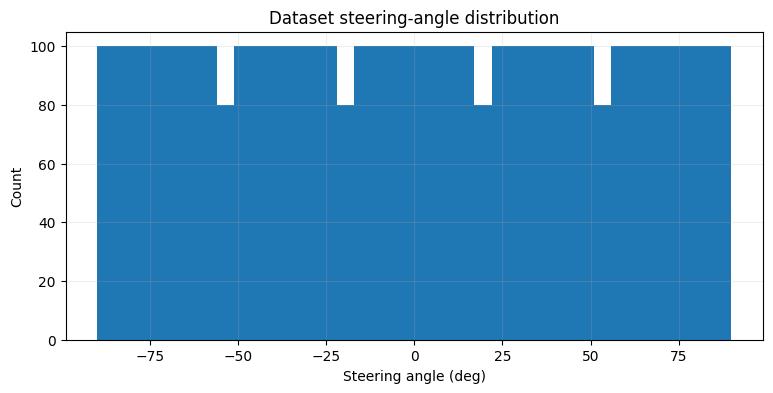

In [37]:
# ============================================================
# 3. Validate Dataset + Distribution
# ============================================================
df = pd.read_csv(LABELS_CSV)
required_cols = {'image', 'angle_deg', 'angle_norm'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f'필수 컬럼 누락: {missing}')

# 파일 존재 여부
exists_mask = df['image'].apply(lambda x: (IMAGES_DIR / str(x)).exists())
if not exists_mask.all():
    print('Warning: missing images =', int((~exists_mask).sum()))
    df = df[exists_mask].reset_index(drop=True)

# 기본 검증
sample_img = Image.open(IMAGES_DIR / df.iloc[0]['image'])
print('Rows:', len(df))
print('Sample image:', sample_img.size, sample_img.mode)
print('Angle degree range:', (df.angle_deg.min(), df.angle_deg.max()))
print('Angle norm range:', (df.angle_norm.min(), df.angle_norm.max()))
print(df.head())

plt.figure(figsize=(9, 4))
plt.hist(df['angle_deg'], bins=37)
plt.xlabel('Steering angle (deg)')
plt.ylabel('Count')
plt.title('Dataset steering-angle distribution')
plt.grid(alpha=0.2)
plt.show()

Train: 2533 Val: 543 Test: 544


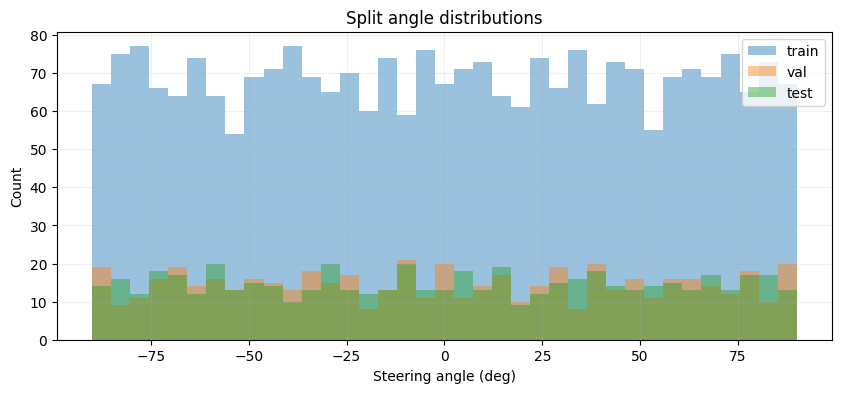

In [38]:
# ============================================================
# 4. Stratified Train / Validation / Test Split
# ============================================================
# 회귀값을 binning해서 각 split의 각도 분포를 최대한 유사하게 유지합니다.
angle_bins = pd.cut(df['angle_deg'], bins=NUM_ANGLE_BINS, labels=False, include_lowest=True)

train_df, temp_df = train_test_split(
    df,
    test_size=(1.0 - TRAIN_RATIO),
    random_state=SEED,
    stratify=angle_bins,
)

temp_bins = pd.cut(temp_df['angle_deg'], bins=NUM_ANGLE_BINS, labels=False, include_lowest=True)
val_fraction_of_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
val_df, test_df = train_test_split(
    temp_df,
    test_size=(1.0 - val_fraction_of_temp),
    random_state=SEED,
    stratify=temp_bins,
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print('Train:', len(train_df), 'Val:', len(val_df), 'Test:', len(test_df))

plt.figure(figsize=(10, 4))
plt.hist(train_df.angle_deg, bins=37, alpha=0.45, label='train')
plt.hist(val_df.angle_deg, bins=37, alpha=0.45, label='val')
plt.hist(test_df.angle_deg, bins=37, alpha=0.45, label='test')
plt.xlabel('Steering angle (deg)')
plt.ylabel('Count')
plt.title('Split angle distributions')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [39]:
# ============================================================
# 5. PyTorch Dataset / DataLoaders
# ============================================================
class SteeringDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, image_dir: Path, train=False):
        self.frame = frame.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        # Geometry augmentation은 angle label을 바꾸므로 사용하지 않습니다.
        # Architecture 비교의 공정성을 위해 기본은 ToTensor만 사용합니다.
        self.transform = transforms.Compose([
            transforms.ToTensor(),  # RGB [0,255] -> float [0,1], CxHxW
        ])

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(self.image_dir / row['image']).convert('RGB')
        x = self.transform(img)
        y_norm = torch.tensor(float(row['angle_norm']), dtype=torch.float32)
        y_deg = torch.tensor(float(row['angle_deg']), dtype=torch.float32)
        return x, y_norm, y_deg

train_ds = SteeringDataset(train_df, IMAGES_DIR, train=True)
val_ds   = SteeringDataset(val_df, IMAGES_DIR, train=False)
test_ds  = SteeringDataset(test_df, IMAGES_DIR, train=False)

pin = torch.cuda.is_available()
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=(NUM_WORKERS>0))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=(NUM_WORKERS>0))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=(NUM_WORKERS>0))

xb, yn, yd = next(iter(train_loader))
print('Batch image:', xb.shape, xb.dtype)
print('Target norm:', yn.shape, yn.min().item(), yn.max().item())
print('Target deg :', yd.shape, yd.min().item(), yd.max().item())

Batch image: torch.Size([128, 3, 64, 64]) torch.float32
Target norm: torch.Size([128]) -1.0 1.0
Target deg : torch.Size([128]) -90.0 90.0


## Architecture 표현

예를 들어 candidate가 아래와 같으면:

```text
Stem Conv: 3→6, stride=1
MaxPool: ON
Extra Conv1: 6→8, stride=1
MaxPool: OFF
Extra Conv2: 8→16, stride=2
Head: AdaptiveAvgPool(2×2) + Flatten
FC: 64→32→1
```

`pool_between`은 **Conv와 다음 Conv 사이**에만 존재합니다. 마지막 Conv 뒤에는 MaxPool을 별도로 넣지 않습니다.

In [40]:
# ============================================================
# 6. Candidate generation
# ============================================================
def fc_hidden_profiles(depth: int):
    # depth는 최종 output FC 포함
    hidden_count = depth - 1
    if hidden_count == 0:
        return [tuple()]
    profiles = []
    for vals in itertools.product(FC_HIDDEN_OPTIONS, repeat=hidden_count):
        if ALLOW_FC_EXPANSION or all(vals[i] >= vals[i+1] for i in range(len(vals)-1)):
            profiles.append(tuple(vals))
    return profiles


def generate_candidates():
    rows = []
    cid = 0
    for stem_stride in STEM_STRIDE_OPTIONS:
        for n_extra in EXTRA_CONV_OPTIONS:
            for channels in itertools.product(CHANNEL_OPTIONS, repeat=n_extra):
                for strides in itertools.product(CONV_STRIDE_OPTIONS, repeat=n_extra):
                    # 총 Conv = 1 stem + n_extra -> Conv 사이 boundary = n_extra
                    for pools in itertools.product(POOL_OPTIONS, repeat=n_extra):
                        for head in HEAD_OPTIONS:
                            for fc_depth in FC_DEPTH_OPTIONS:
                                for fc_hidden in fc_hidden_profiles(fc_depth):
                                    rows.append({
                                        'id': cid,
                                        'stem_stride': int(stem_stride),
                                        'n_extra_conv': int(n_extra),
                                        'channels': tuple(int(x) for x in channels),
                                        'strides': tuple(int(x) for x in strides),
                                        'pool_between': tuple(int(x) for x in pools),
                                        'head': head,
                                        'fc_depth': int(fc_depth),
                                        'fc_hidden': tuple(int(x) for x in fc_hidden),
                                    })
                                    cid += 1
    return pd.DataFrame(rows)

candidates = generate_candidates()
print('Total architecture candidates:', len(candidates))
print(candidates.head())

Total architecture candidates: 67824
   id  stem_stride  n_extra_conv channels strides pool_between head  fc_depth  \
0   0            1             1     (4,)    (1,)         (0,)  gap         1   
1   1            1             1     (4,)    (1,)         (0,)  gap         2   
2   2            1             1     (4,)    (1,)         (0,)  gap         2   
3   3            1             1     (4,)    (1,)         (0,)  gap         3   
4   4            1             1     (4,)    (1,)         (0,)  gap         3   

  fc_hidden  
0        ()  
1     (16,)  
2     (32,)  
3  (16, 16)  
4  (32, 16)  


In [41]:
# ============================================================
# 7. Zybo Z7-20 HW cost estimator
# ============================================================
def conv_out_size(h, w, k=3, p=1, s=1):
    oh = math.floor((h + 2*p - k) / s + 1)
    ow = math.floor((w + 2*p - k) / s + 1)
    return oh, ow


def pool_out_size(h, w, k=2, s=2):
    oh = math.floor((h - k) / s + 1)
    ow = math.floor((w - k) / s + 1)
    return oh, ow


def estimate_hw(cfg: Dict[str, Any]):
    h, w, c = 64, 64, 3
    activation_maps = [(h, w, c, 'input')]
    conv_specs = []

    # Stem: 3 -> 6
    conv_specs.append((c, 6, int(cfg['stem_stride'])))
    # Extra Conv(s)
    cin = 6
    for cout, s in zip(cfg['channels'], cfg['strides']):
        conv_specs.append((cin, int(cout), int(s)))
        cin = int(cout)

    total_macs = 0
    conv_weight_count = 0
    bias_count = 0
    max_line_buffer_bytes = 0
    shape_trace = []

    for i, (cin, cout, stride) in enumerate(conv_specs):
        # 3x3 line buffer: (K-1) rows × width × input channels × INT8 1B
        line_b = 2 * w * cin
        max_line_buffer_bytes = max(max_line_buffer_bytes, line_b)

        oh, ow = conv_out_size(h, w, k=3, p=1, s=stride)
        macs = oh * ow * cout * 3 * 3 * cin
        weights = 3 * 3 * cin * cout

        total_macs += macs
        conv_weight_count += weights
        bias_count += cout
        shape_trace.append(f'Conv{i}: {h}x{w}x{cin} -> {oh}x{ow}x{cout} s{stride}')
        h, w, c = oh, ow, cout
        activation_maps.append((h, w, c, f'conv{i}'))

        # 마지막 Conv 뒤가 아니라 Conv 사이에만 pool 여부를 적용
        if i < len(conv_specs)-1 and int(cfg['pool_between'][i]) == 1:
            ph, pw = pool_out_size(h, w, k=2, s=2)
            shape_trace.append(f'Pool{i}: {h}x{w}x{c} -> {ph}x{pw}x{c}')
            h, w = ph, pw
            activation_maps.append((h, w, c, f'pool{i}'))

    # 지나친 downsampling reject
    spatial_ok = (h >= 2 and w >= 2)

    # Head
    head = cfg['head']
    if head == 'gap':
        head_dim = c
    elif head == 'adaptive2':
        head_dim = 2 * 2 * c
    elif head == 'flatten':
        head_dim = h * w * c
    else:
        raise ValueError(head)

    # FC weights / MACs
    fc_dims = [head_dim] + list(cfg['fc_hidden']) + [1]
    fc_weight_count = 0
    for din, dout in zip(fc_dims[:-1], fc_dims[1:]):
        fc_weight_count += din * dout
        bias_count += dout
        total_macs += din * dout

    total_weight_count = conv_weight_count + fc_weight_count
    int8_weight_bytes = total_weight_count                 # 1 byte / weight
    int32_bias_bytes = bias_count * 4                     # typical accumulator-domain bias
    model_param_bytes = int8_weight_bytes + int32_bias_bytes

    # INT8 activation feature-map storage
    act_sizes = [hh * ww * cc for hh, ww, cc, _ in activation_maps]
    peak_activation_bytes = max(act_sizes)
    # 보수적 정적 A/B bank 할당: 두 bank 모두 max feature map 크기
    pingpong_bytes = 2 * peak_activation_bytes
    # 실제 adjacent pair 동시 점유의 lower bound 참고용
    pair_peak_bytes = max((act_sizes[i] + act_sizes[i+1]) for i in range(len(act_sizes)-1)) if len(act_sizes)>1 else act_sizes[0]

    # Streaming weights: 전체 weight 대신 local tile buffer만 BRAM 상주한다고 가정
    runtime_bram_stream_bytes = pingpong_bytes + max_line_buffer_bytes + LOCAL_WEIGHT_BUFFER_BYTES
    runtime_bram_all_weights_bytes = runtime_bram_stream_bytes + model_param_bytes

    # BRAM utilization relative to total Zybo Z7-20 BRAM
    bram_util_stream_frac = runtime_bram_stream_bytes / ZYBO_BRAM_BYTES
    bram_util_all_weights_frac = runtime_bram_all_weights_bytes / ZYBO_BRAM_BYTES

    # 55% is the hard CNN BRAM ceiling.
    # 45~55% is reported as the target band, but <45% remains valid.
    bram_in_target_band_stream = (
        BRAM_TARGET_LOW_FRACTION <= bram_util_stream_frac <= BRAM_HARD_MAX_FRACTION
    )
    bram_in_target_band_all_weights = (
        BRAM_TARGET_LOW_FRACTION <= bram_util_all_weights_frac <= BRAM_HARD_MAX_FRACTION
    )

    hw_ok_stream = spatial_ok and (runtime_bram_stream_bytes <= CNN_BRAM_BUDGET_BYTES)
    hw_ok_all_weights = spatial_ok and (runtime_bram_all_weights_bytes <= CNN_BRAM_BUDGET_BYTES)
    ddr_ok = model_param_bytes + pingpong_bytes <= ZYBO_DDR_BYTES

    latency_s = total_macs / (EFFECTIVE_MACS_PER_CYCLE * PL_CLOCK_HZ)
    latency_ms = latency_s * 1e3
    est_cycles = total_macs / EFFECTIVE_MACS_PER_CYCLE

    return {
        'final_h': h,
        'final_w': w,
        'final_c': c,
        'head_dim': head_dim,
        'conv_weight_count': conv_weight_count,
        'fc_weight_count': fc_weight_count,
        'weight_count': total_weight_count,
        'int8_weight_kb': int8_weight_bytes / 1024,
        'bias_kb_int32': int32_bias_bytes / 1024,
        'model_param_kb': model_param_bytes / 1024,
        'peak_activation_kb': peak_activation_bytes / 1024,
        'pingpong_kb': pingpong_bytes / 1024,
        'pair_peak_kb': pair_peak_bytes / 1024,
        'line_buffer_kb': max_line_buffer_bytes / 1024,
        'runtime_bram_stream_kb': runtime_bram_stream_bytes / 1024,
        'runtime_bram_all_weights_kb': runtime_bram_all_weights_bytes / 1024,
        'bram_util_stream_pct': bram_util_stream_frac * 100.0,
        'bram_util_all_weights_pct': bram_util_all_weights_frac * 100.0,
        'BRAM_IN_TARGET_45_55_STREAM': bool(bram_in_target_band_stream),
        'BRAM_IN_TARGET_45_55_ALL_WEIGHTS': bool(bram_in_target_band_all_weights),
        'macs': int(total_macs),
        'macs_m': total_macs / 1e6,
        'estimated_cycles': est_cycles,
        'estimated_latency_ms': latency_ms,
        'spatial_ok': spatial_ok,
        'HW_OK_STREAM': bool(hw_ok_stream and ddr_ok),
        'HW_OK_ALL_WEIGHTS': bool(hw_ok_all_weights and ddr_ok),
        'shape_trace': ' | '.join(shape_trace),
    }

hw_rows = [estimate_hw(row.to_dict()) for _, row in candidates.iterrows()]
hw_df = pd.DataFrame(hw_rows)
candidates_hw = pd.concat([candidates.reset_index(drop=True), hw_df], axis=1)

print('Total candidates:', len(candidates_hw))
print('HW_OK_STREAM:', int(candidates_hw.HW_OK_STREAM.sum()))
print('HW_OK_ALL_WEIGHTS:', int(candidates_hw.HW_OK_ALL_WEIGHTS.sum()))

display(candidates_hw[[
    'id','stem_stride','n_extra_conv','channels','strides','pool_between','head','fc_hidden',
    'final_h','final_w','final_c','int8_weight_kb','pingpong_kb','line_buffer_kb',
    'macs_m','estimated_latency_ms','HW_OK_STREAM','HW_OK_ALL_WEIGHTS'
]].head(12))

candidates_hw.to_csv(OUTPUT_DIR / 'all_candidates_hw.csv', index=False)


Total candidates: 67824
HW_OK_STREAM: 63936
HW_OK_ALL_WEIGHTS: 63422


,id,stem_stride,n_extra_conv,channels,strides,pool_between,head,fc_hidden,final_h,final_w,final_c,int8_weight_kb,pingpong_kb,line_buffer_kb,macs_m,estimated_latency_ms,HW_OK_STREAM,HW_OK_ALL_WEIGHTS
0,0,1,1,"(4,)","(1,)","(0,)",gap,(),64,64,4,0.373047,48.0,0.75,1.548292,2.293766,True,True
1,1,1,1,"(4,)","(1,)","(0,)",gap,"(16,)",64,64,4,0.447266,48.0,0.75,1.548368,2.293879,True,True
2,2,1,1,"(4,)","(1,)","(0,)",gap,"(32,)",64,64,4,0.525391,48.0,0.75,1.548448,2.293997,True,True
3,3,1,1,"(4,)","(1,)","(0,)",gap,"(16, 16)",64,64,4,0.697266,48.0,0.75,1.548624,2.294258,True,True
4,4,1,1,"(4,)","(1,)","(0,)",gap,"(32, 16)",64,64,4,1.009766,48.0,0.75,1.548944,2.294732,True,True
5,5,1,1,"(4,)","(1,)","(0,)",gap,"(32, 32)",64,64,4,1.525391,48.0,0.75,1.549472,2.295514,True,True
6,6,1,1,"(4,)","(1,)","(0,)",adaptive2,(),64,64,4,0.384766,48.0,0.75,1.548304,2.293784,True,True
7,7,1,1,"(4,)","(1,)","(0,)",adaptive2,"(16,)",64,64,4,0.634766,48.0,0.75,1.548560,2.294163,True,True
8,8,1,1,"(4,)","(1,)","(0,)",adaptive2,"(32,)",64,64,4,0.900391,48.0,0.75,1.548832,2.294566,True,True
9,9,1,1,"(4,)","(1,)","(0,)",adaptive2,"(16, 16)",64,64,4,0.884766,48.0,0.75,1.548816,2.294542,True,True


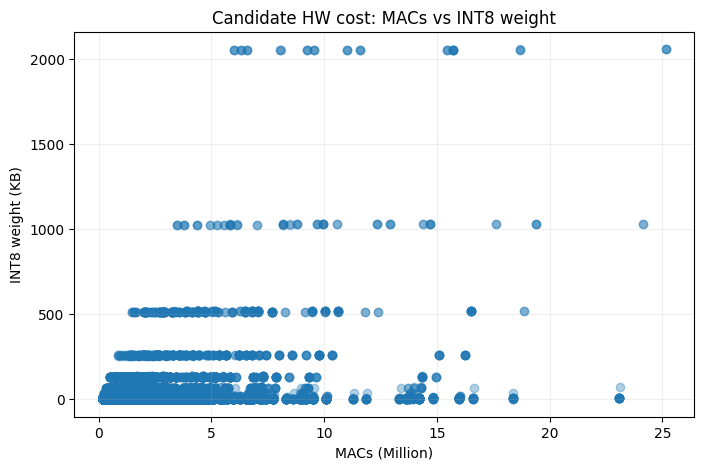

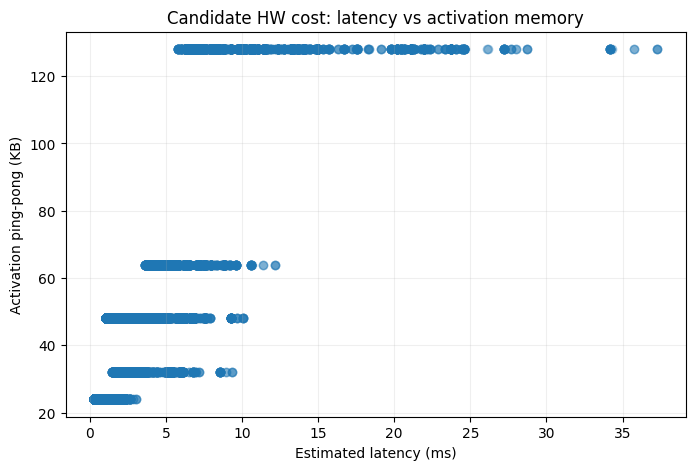

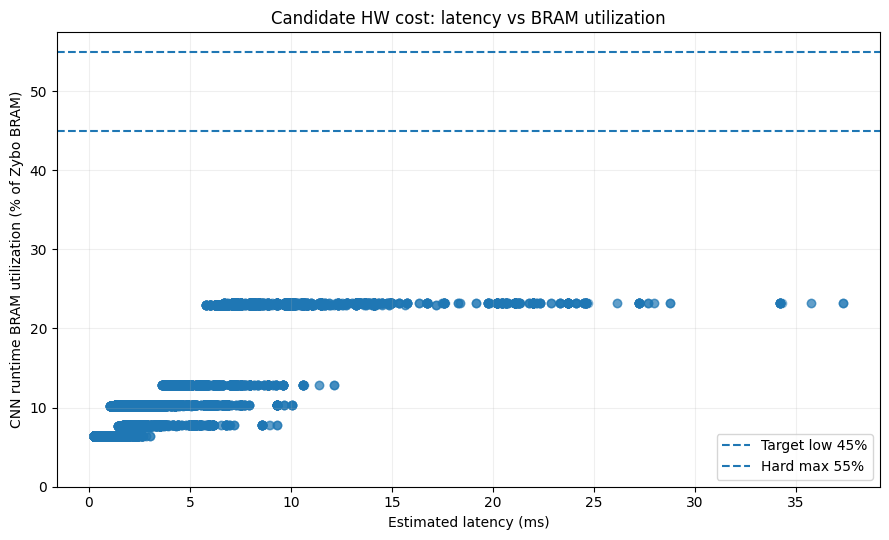

HW_OK under 55% BRAM cap: 63936 / 67824
45~55% target-band candidates: 0
<45% BRAM candidates: 63936


In [42]:
# ============================================================
# 8. HW exploration plots
# ============================================================
hw_ok = candidates_hw[candidates_hw.HW_OK_STREAM].copy()

fig = plt.figure(figsize=(8, 5))
plt.scatter(hw_ok['macs_m'], hw_ok['int8_weight_kb'], alpha=0.35)
plt.xlabel('MACs (Million)')
plt.ylabel('INT8 weight (KB)')
plt.title('Candidate HW cost: MACs vs INT8 weight')
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(hw_ok['estimated_latency_ms'], hw_ok['pingpong_kb'], alpha=0.35)
plt.xlabel('Estimated latency (ms)')
plt.ylabel('Activation ping-pong (KB)')
plt.title('Candidate HW cost: latency vs activation memory')
plt.grid(alpha=0.2)
plt.show()

# BRAM utilization distribution
plt.figure(figsize=(9, 5.5))
plt.scatter(
    hw_ok['estimated_latency_ms'],
    hw_ok['bram_util_stream_pct'],
    alpha=0.45
)
plt.axhline(45.0, linestyle='--', label='Target low 45%')
plt.axhline(55.0, linestyle='--', label='Hard max 55%')
plt.xlabel('Estimated latency (ms)')
plt.ylabel('CNN runtime BRAM utilization (% of Zybo BRAM)')
plt.title('Candidate HW cost: latency vs BRAM utilization')
plt.ylim(bottom=0)
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hw_latency_vs_bram_util.png', dpi=170, bbox_inches='tight')
plt.show()

print('HW_OK under 55% BRAM cap:', len(hw_ok), '/', len(candidates_hw))
print('45~55% target-band candidates:',
      int(hw_ok['BRAM_IN_TARGET_45_55_STREAM'].sum()))
print('<45% BRAM candidates:',
      int((hw_ok['bram_util_stream_pct'] < 45.0).sum()))


In [43]:
# ============================================================
# 9. Candidate Model Builder
# ============================================================
class CandidateCNN(nn.Module):
    def __init__(self, cfg: Dict[str, Any]):
        super().__init__()
        layers = []

        conv_specs = [(3, 6, int(cfg['stem_stride']))]
        cin = 6
        for cout, s in zip(cfg['channels'], cfg['strides']):
            conv_specs.append((cin, int(cout), int(s)))
            cin = int(cout)

        for i, (cin, cout, stride) in enumerate(conv_specs):
            layers += [
                nn.Conv2d(cin, cout, kernel_size=3, stride=stride, padding=1, bias=True),
                nn.ReLU(inplace=True),
            ]
            if i < len(conv_specs)-1 and int(cfg['pool_between'][i]) == 1:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        self.features = nn.Sequential(*layers)

        head = cfg['head']
        if head == 'gap':
            self.head = nn.AdaptiveAvgPool2d((1, 1))
        elif head == 'adaptive2':
            self.head = nn.AdaptiveAvgPool2d((2, 2))
        elif head == 'flatten':
            self.head = nn.Identity()
        else:
            raise ValueError(head)

        # head_dim은 estimator와 동일하게 계산
        hw = estimate_hw(cfg)
        head_dim = int(hw['head_dim'])

        dims = [head_dim] + list(cfg['fc_hidden']) + [1]
        fc_layers = []
        for j, (din, dout) in enumerate(zip(dims[:-1], dims[1:])):
            fc_layers.append(nn.Linear(din, dout))
            if j < len(dims) - 2:  # final regression output에는 ReLU 없음
                fc_layers.append(nn.ReLU(inplace=True))
        self.regressor = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        x = torch.flatten(x, 1)
        x = self.regressor(x)
        return x.squeeze(1)   # angle_norm prediction, linear signed output


def config_from_row(row):
    keys = ['id','stem_stride','n_extra_conv','channels','strides','pool_between','head','fc_depth','fc_hidden']
    d = {k: row[k] for k in keys}
    # CSV/Series에서 list/string으로 변했을 때 방지
    for k in ['channels','strides','pool_between','fc_hidden']:
        if isinstance(d[k], list): d[k] = tuple(d[k])
    return d

# smoke test
smoke_cfg = config_from_row(candidates_hw[candidates_hw.HW_OK_STREAM].iloc[0])
smoke_model = CandidateCNN(smoke_cfg).to(DEVICE)
with torch.no_grad():
    y = smoke_model(torch.zeros(2, 3, 64, 64, device=DEVICE))
print(smoke_model)
print('Smoke output:', y.shape)
del smoke_model
if torch.cuda.is_available(): torch.cuda.empty_cache()

CandidateCNN(
  (features): Sequential(
    (0): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(6, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
  )
  (head): AdaptiveAvgPool2d(output_size=(1, 1))
  (regressor): Sequential(
    (0): Linear(in_features=4, out_features=1, bias=True)
  )
)
Smoke output: torch.Size([2])


In [44]:
# ============================================================
# 10. Metrics / Training helpers
# ============================================================
def batch_metrics(pred_norm, target_norm):
    pred_deg = pred_norm * 90.0
    target_deg = target_norm * 90.0
    err = torch.abs(pred_deg - target_deg)
    return {
        'mae_deg_sum': err.sum().item(),
        'acc3_count': (err <= 3.0).sum().item(),
        'acc5_count': (err <= 5.0).sum().item(),
        'acc10_count': (err <= 10.0).sum().item(),
        'n': target_norm.numel(),
    }

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    n_total = 0
    mae_sum = 0.0
    a3 = a5 = a10 = 0
    preds_all, targets_all = [], []

    for x, y_norm, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        y_norm = y_norm.to(DEVICE, non_blocking=True)
        pred = model(x)
        loss = criterion(pred, y_norm)

        bs = y_norm.size(0)
        total_loss += loss.item() * bs
        n_total += bs
        m = batch_metrics(pred, y_norm)
        mae_sum += m['mae_deg_sum']
        a3 += m['acc3_count']; a5 += m['acc5_count']; a10 += m['acc10_count']
        preds_all.append((pred.detach().cpu().numpy() * 90.0))
        targets_all.append((y_norm.detach().cpu().numpy() * 90.0))

    preds = np.concatenate(preds_all)
    targets = np.concatenate(targets_all)
    return {
        'loss': total_loss / n_total,
        'mae_deg': mae_sum / n_total,
        'acc3': 100.0 * a3 / n_total,
        'acc5': 100.0 * a5 / n_total,
        'acc10': 100.0 * a10 / n_total,
        'r2': r2_score(targets, preds),
        'pred_deg': preds,
        'target_deg': targets,
    }


def train_one_candidate(cfg, epochs, run_name, save_best=True, patience=None):
    model = CandidateCNN(cfg).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, epochs))

    history = []
    best_val_mae = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_n = 0
        train_mae_sum = 0.0
        train_a3 = train_a5 = train_a10 = 0

        for x, y_norm, _ in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y_norm = y_norm.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred = model(x)
            loss = criterion(pred, y_norm)
            loss.backward()
            optimizer.step()

            bs = y_norm.size(0)
            train_loss_sum += loss.item() * bs
            train_n += bs
            m = batch_metrics(pred.detach(), y_norm)
            train_mae_sum += m['mae_deg_sum']
            train_a3 += m['acc3_count']; train_a5 += m['acc5_count']; train_a10 += m['acc10_count']

        val = evaluate(model, val_loader, criterion)
        row = {
            'epoch': epoch,
            'lr': optimizer.param_groups[0]['lr'],
            'train_loss': train_loss_sum / train_n,
            'train_mae_deg': train_mae_sum / train_n,
            'train_acc3': 100.0 * train_a3 / train_n,
            'train_acc5': 100.0 * train_a5 / train_n,
            'train_acc10': 100.0 * train_a10 / train_n,
            'val_loss': val['loss'],
            'val_mae_deg': val['mae_deg'],
            'val_acc3': val['acc3'],
            'val_acc5': val['acc5'],
            'val_acc10': val['acc10'],
            'val_r2': val['r2'],
        }
        history.append(row)
        scheduler.step()

        print(f"[{run_name}] {epoch:02d}/{epochs} "
              f"loss {row['train_loss']:.4f}/{row['val_loss']:.4f} | "
              f"MAE {row['train_mae_deg']:.2f}/{row['val_mae_deg']:.2f}° | "
              f"Acc±5 {row['train_acc5']:.1f}/{row['val_acc5']:.1f}%")

        if val['mae_deg'] < best_val_mae:
            best_val_mae = val['mae_deg']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if patience is not None and no_improve >= patience:
                print(f'Early stop at epoch {epoch}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    best_val = evaluate(model, val_loader, criterion)

    hist_df = pd.DataFrame(history)
    hist_path = OUTPUT_DIR / f'{run_name}_history.csv'
    hist_df.to_csv(hist_path, index=False)

    if save_best:
        # PyTorch 2.6+ 권장 형식: Tensor state_dict만 저장
        torch.save(model.state_dict(), OUTPUT_DIR / f'{run_name}_best.pt')

    return model, hist_df, best_val

def load_model_state_dict_compat(ckpt_path, map_location='cpu'):
    """
    PyTorch 2.6+ compatible loader.

    - 새 형식: raw state_dict -> weights_only=True
    - 이전 노트북 형식: {'config': ..., 'state_dict': ...}
      본 노트북이 직접 만든 trusted checkpoint에 한해
      weights_only=False fallback
    """
    try:
        obj = torch.load(
            ckpt_path,
            map_location=map_location,
            weights_only=True,
        )
    except Exception as e:
        print('[Checkpoint] New safe loader failed:', type(e).__name__)
        print('[Checkpoint] Loading legacy checkpoint created by this notebook...')
        obj = torch.load(
            ckpt_path,
            map_location=map_location,
            weights_only=False,
        )

    if isinstance(obj, dict) and 'state_dict' in obj:
        return obj['state_dict']

    return obj


In [45]:
# ============================================================
# 11. Learning-curve plot helper
# ============================================================
def plot_history(hist_df, title, save_path=None):
    # 1) Loss
    plt.figure(figsize=(8, 4.5))
    plt.plot(hist_df.epoch, hist_df.train_loss, marker='o', label='Train')
    plt.plot(hist_df.epoch, hist_df.val_loss, marker='o', label='Validation')
    plt.xlabel('Epoch'); plt.ylabel('MSE loss'); plt.title(f'{title} — Loss')
    plt.grid(alpha=0.2); plt.legend(); plt.tight_layout()
    if save_path: plt.savefig(str(save_path).replace('.png', '_loss.png'), dpi=160, bbox_inches='tight')
    plt.show()

    # 2) MAE degree
    plt.figure(figsize=(8, 4.5))
    plt.plot(hist_df.epoch, hist_df.train_mae_deg, marker='o', label='Train MAE')
    plt.plot(hist_df.epoch, hist_df.val_mae_deg, marker='o', label='Validation MAE')
    plt.xlabel('Epoch'); plt.ylabel('MAE (degree)'); plt.title(f'{title} — MAE')
    plt.grid(alpha=0.2); plt.legend(); plt.tight_layout()
    if save_path: plt.savefig(str(save_path).replace('.png', '_mae.png'), dpi=160, bbox_inches='tight')
    plt.show()

    # 3) Accuracy ±3/5/10
    plt.figure(figsize=(9, 5))
    plt.plot(hist_df.epoch, hist_df.val_acc3, marker='o', label='Val ±3°')
    plt.plot(hist_df.epoch, hist_df.val_acc5, marker='o', label='Val ±5°')
    plt.plot(hist_df.epoch, hist_df.val_acc10, marker='o', label='Val ±10°')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.ylim(0, 100)
    plt.title(f'{title} — Validation tolerance accuracy')
    plt.grid(alpha=0.2); plt.legend(); plt.tight_layout()
    if save_path: plt.savefig(str(save_path).replace('.png', '_accuracy.png'), dpi=160, bbox_inches='tight')
    plt.show()

In [46]:

# ============================================================
# 12. Select a STRUCTURALLY diverse HW-feasible screening subset
# ============================================================
def _max_channel(chs):
    return int(max(tuple(chs))) if len(tuple(chs)) else 6

def _downsample_count(row):
    # stride=2 또는 MaxPool이 실제 spatial reduction을 만드는 횟수의 proxy
    return (
        int(int(row['stem_stride']) == 2)
        + sum(int(s) == 2 for s in tuple(row['strides']))
        + sum(int(p) == 1 for p in tuple(row['pool_between']))
    )

def select_screen_candidates(hw_table: pd.DataFrame, max_models=48):
    pool = hw_table[hw_table.HW_OK_STREAM].copy().reset_index(drop=True)

    if max_models is None or len(pool) <= max_models:
        return pool.sample(frac=1, random_state=SEED).reset_index(drop=True)

    # --------------------------------------------------------
    # 핵심:
    # MAC/weight가 비슷한 후보만 뽑지 않고,
    # stem stride / channel scale / head / conv depth를 먼저 균등하게 섞습니다.
    # --------------------------------------------------------
    pool['max_channel'] = pool['channels'].apply(_max_channel)
    pool['downsample_count'] = pool.apply(_downsample_count, axis=1)

    group_cols = ['stem_stride', 'max_channel', 'head', 'n_extra_conv']
    groups = list(pool.groupby(group_cols, observed=True))

    chosen = []
    target_per_group = max(1, max_models // max(1, len(groups)))

    for _, g in groups:
        # 같은 구조 그룹 안에서는 downsampling이 적은 구조와 많은 구조가
        # 모두 포함되도록 정렬 후 양 끝에서 선택합니다.
        g = g.sort_values(
            ['downsample_count', 'estimated_latency_ms', 'int8_weight_kb'],
            ascending=[True, True, True]
        )

        if len(g) <= target_per_group:
            picked = g
        elif target_per_group == 1:
            picked = g.iloc[[len(g)//2]]
        else:
            # 균등 index sampling: low ↔ high downsampling/HW cost 모두 포함
            idxs = np.linspace(0, len(g)-1, target_per_group, dtype=int)
            picked = g.iloc[np.unique(idxs)]

        chosen.append(picked)

    out = pd.concat(chosen, ignore_index=True).drop_duplicates('id')

    # 그룹당 1~2개만으로 부족하면 아직 덜 포함된 구조를 우선 보충
    if len(out) < max_models:
        remain = pool[~pool.id.isin(out.id)].copy()

        # 이미 선택된 구조 그룹의 빈도를 계산하고, 적은 그룹 우선
        selected_counts = (
            out.groupby(group_cols, observed=True)
               .size()
               .rename('selected_n')
               .reset_index()
        )
        remain = remain.merge(selected_counts, on=group_cols, how='left')
        remain['selected_n'] = remain['selected_n'].fillna(0)

        remain = remain.sort_values(
            ['selected_n', 'downsample_count', 'estimated_latency_ms'],
            ascending=[True, True, True]
        )
        need = max_models - len(out)
        out = pd.concat([out, remain.head(need)], ignore_index=True)

    # 초과 시 구조 그룹 다양성을 최대한 유지하면서 deterministic cut
    if len(out) > max_models:
        out = out.sample(frac=1, random_state=SEED).head(max_models)

    out = out.sample(frac=1, random_state=SEED).reset_index(drop=True)
    return out


screen_df = select_screen_candidates(candidates_hw, MAX_SCREEN_MODELS)

print('Stage 1 screening models:', len(screen_df))
print('\nStem stride counts')
print(screen_df['stem_stride'].value_counts().sort_index())
print('\nMax channel counts')
print(screen_df['channels'].apply(_max_channel).value_counts().sort_index())
print('\nHead counts')
print(screen_df['head'].value_counts())

display(screen_df[[
    'id','stem_stride','channels','strides','pool_between','head','fc_hidden',
    'macs_m','int8_weight_kb','pingpong_kb','runtime_bram_stream_kb','bram_util_stream_pct','BRAM_IN_TARGET_45_55_STREAM','estimated_latency_ms'
]].head(15))

screen_df.to_csv(OUTPUT_DIR / 'screen_candidates.csv', index=False)


Stage 1 screening models: 48

Stem stride counts
stem_stride
1    25
2    23
Name: count, dtype: int64

Max channel counts
channels
4     16
8     15
16    17
Name: count, dtype: int64

Head counts
head
flatten      17
adaptive2    16
gap          15
Name: count, dtype: int64


,id,stem_stride,channels,strides,pool_between,head,fc_hidden,macs_m,int8_weight_kb,pingpong_kb,runtime_bram_stream_kb,bram_util_stream_pct,BRAM_IN_TARGET_45_55_STREAM,estimated_latency_ms
0,18691,1,"(8, 8, 8)","(2, 2, 1)","(0, 1, 0)",adaptive2,"(16,)",1.180176,2.220703,48.0,64.750,10.277778,False,1.748409
1,37224,2,"(4, 4, 4)","(1, 2, 2)","(1, 0, 0)",gap,(),0.232708,0.654297,24.0,40.375,6.408730,False,0.344753
2,2162,1,"(16, 4)","(2, 2)","(0, 0)",gap,"(32,)",1.695904,1.720703,48.0,65.000,10.317460,False,2.512450
3,1142,1,"(8, 4)","(1, 1)","(1, 1)",adaptive2,"(32,)",1.180192,1.392578,48.0,64.375,10.218254,False,1.748433
4,33944,2,"(4,)","(1,)","(1,)",flatten,"(32,)",0.253984,32.400391,24.0,40.375,6.408730,False,0.376273
5,3573,1,"(4, 4, 4)","(2, 1, 2)","(0, 1, 0)",adaptive2,"(16, 16)",0.931344,1.166016,48.0,64.750,10.277778,False,1.379769
6,32404,1,"(16, 16, 8)","(2, 1, 2)","(1, 0, 0)",gap,"(32, 16)",1.549072,5.142578,48.0,64.500,10.238095,False,2.294921
7,33933,2,"(4,)","(1,)","(1,)",gap,"(16, 16)",0.221520,0.697266,24.0,40.375,6.408730,False,0.328178
8,40934,2,"(4, 8, 4)","(2, 1, 2)","(0, 1, 0)",gap,"(32,)",0.244384,1.087891,24.0,40.375,6.408730,False,0.362050
9,34010,2,"(8,)","(1,)","(1,)",adaptive2,"(32,)",0.277536,1.611328,24.0,40.375,6.408730,False,0.411164


In [47]:
# ============================================================
# 13. Stage 1 — Short screening training
# ============================================================
screen_results = []

for idx, row in screen_df.iterrows():
    cfg = config_from_row(row)
    cid = int(cfg['id'])
    print('\n' + '='*90)
    print(f'SCREEN {idx+1}/{len(screen_df)} | candidate {cid}')
    print(cfg)

    model, hist, val = train_one_candidate(
        cfg, epochs=SCREEN_EPOCHS,
        run_name=f'screen_id{cid:04d}',
        save_best=False,
        patience=None,
    )

    result = row.to_dict()
    result.update({
        'val_loss': val['loss'],
        'val_mae_deg': val['mae_deg'],
        'val_acc3': val['acc3'],
        'val_acc5': val['acc5'],
        'val_acc10': val['acc10'],
        'val_r2': val['r2'],
    })
    screen_results.append(result)

    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()

screen_results_df = pd.DataFrame(screen_results)
screen_results_df.to_csv(OUTPUT_DIR / 'screen_results_raw.csv', index=False)
print('Screening complete:', len(screen_results_df))


SCREEN 1/48 | candidate 18691
{'id': 18691, 'stem_stride': 1, 'n_extra_conv': 3, 'channels': (8, 8, 8), 'strides': (2, 2, 1), 'pool_between': (0, 1, 0), 'head': 'adaptive2', 'fc_depth': 2, 'fc_hidden': (16,)}
[screen_id18691] 01/3 loss 0.3987/0.3777 | MAE 47.95/47.19° | Acc±5 6.0/5.9%
[screen_id18691] 02/3 loss 0.3526/0.3474 | MAE 45.87/45.69° | Acc±5 5.5/5.9%
[screen_id18691] 03/3 loss 0.3407/0.3371 | MAE 45.40/45.26° | Acc±5 5.5/5.5%

SCREEN 2/48 | candidate 37224
{'id': 37224, 'stem_stride': 2, 'n_extra_conv': 3, 'channels': (4, 4, 4), 'strides': (1, 2, 2), 'pool_between': (1, 0, 0), 'head': 'gap', 'fc_depth': 1, 'fc_hidden': ()}
[screen_id37224] 01/3 loss 0.3750/0.3686 | MAE 46.98/46.60° | Acc±5 6.0/5.3%
[screen_id37224] 02/3 loss 0.3649/0.3640 | MAE 46.49/46.39° | Acc±5 5.5/5.5%
[screen_id37224] 03/3 loss 0.3619/0.3626 | MAE 46.35/46.33° | Acc±5 5.5/5.5%

SCREEN 3/48 | candidate 2162
{'id': 2162, 'stem_stride': 1, 'n_extra_conv': 2, 'channels': (16, 4), 'strides': (2, 2), 'pool_b

In [48]:

# ============================================================
# 14. Accuracy Gate + HW Score + Pareto Front
# ============================================================
def minmax_benefit(series):
    # 큰 값이 좋음
    s = pd.to_numeric(series, errors='coerce').astype(float)
    lo, hi = s.min(), s.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or abs(hi-lo) < 1e-12:
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - lo) / (hi - lo)


def minmax_cost(series):
    # 작은 값이 좋음
    return 1.0 - minmax_benefit(series)


def pareto_mask(df, benefit_cols, cost_cols):
    '''
    benefit_cols: 클수록 좋음 (예: val_acc5)
    cost_cols   : 작을수록 좋음 (예: latency, memory, MAE)

    다른 후보가 모든 목적에서 같거나 우수하고,
    적어도 하나에서 엄격히 우수하면 현재 후보는 dominated.
    '''
    if len(df) == 0:
        return pd.Series(dtype=bool)

    vals_b = df[benefit_cols].astype(float).to_numpy()
    vals_c = df[cost_cols].astype(float).to_numpy()
    n = len(df)
    keep = np.ones(n, dtype=bool)

    for i in range(n):
        if not keep[i]:
            continue
        for j in range(n):
            if i == j:
                continue

            no_worse_b = np.all(vals_b[j] >= vals_b[i])
            no_worse_c = np.all(vals_c[j] <= vals_c[i])
            strictly_better = np.any(vals_b[j] > vals_b[i]) or np.any(vals_c[j] < vals_c[i])

            if no_worse_b and no_worse_c and strictly_better:
                keep[i] = False
                break

    return pd.Series(keep, index=df.index)


def add_selection_metrics(table: pd.DataFrame):
    '''
    1) Accuracy gate
    2) optional MAE gate
    3) gate 통과 후보 내부에서만 HW Score 정규화
    4) Pareto Front 표기
    '''
    out = table.copy()

    if len(out) == 0:
        return out

    best_acc = float(out[FINAL_SCORE_ACCURACY_KEY].max())
    acc_floor = best_acc - ACCURACY_TOLERANCE_PP

    out['accuracy_best'] = best_acc
    out['accuracy_gate_floor'] = acc_floor
    out['accuracy_gap_pp'] = best_acc - out[FINAL_SCORE_ACCURACY_KEY]
    out['accuracy_gate'] = out[FINAL_SCORE_ACCURACY_KEY] >= acc_floor

    # Accuracy gate 내부에서 MAE 기준을 잡습니다.
    acc_pool = out[out['accuracy_gate']].copy()
    best_mae_in_acc_gate = float(acc_pool['val_mae_deg'].min())
    mae_ceiling = best_mae_in_acc_gate + MAE_TOLERANCE_DEG

    out['mae_best_in_acc_gate'] = best_mae_in_acc_gate
    out['mae_gate_ceiling'] = mae_ceiling
    out['mae_gate'] = out['val_mae_deg'] <= mae_ceiling

    if ENFORCE_MAE_GATE:
        out['eligible'] = out['accuracy_gate'] & out['mae_gate']
    else:
        out['eligible'] = out['accuracy_gate']

    # 혹시 MAE gate가 너무 빡세서 0개가 되는 경우 Accuracy gate로 fallback
    if int(out['eligible'].sum()) == 0:
        print('[WARN] MAE gate 통과 후보가 0개라 Accuracy gate만 사용합니다.')
        out['eligible'] = out['accuracy_gate']

    # --------------------------------------------------------
    # HW Score:
    # MACs는 estimated_latency에 이미 반영되므로 중복 계산하지 않습니다.
    # --------------------------------------------------------
    out['score_latency'] = np.nan
    out['score_activation'] = np.nan
    out['score_weight'] = np.nan
    out['score_mae'] = np.nan
    out['hw_score'] = np.nan

    elig_idx = out.index[out['eligible']]
    elig = out.loc[elig_idx]

    out.loc[elig_idx, 'score_latency'] = minmax_cost(elig['estimated_latency_ms'])
    out.loc[elig_idx, 'score_activation'] = minmax_cost(elig['pingpong_kb'])
    out.loc[elig_idx, 'score_weight'] = minmax_cost(elig['int8_weight_kb'])
    out.loc[elig_idx, 'score_mae'] = minmax_cost(elig['val_mae_deg'])

    out.loc[elig_idx, 'hw_score'] = 100.0 * (
        HW_SCORE_WEIGHTS['latency'] * out.loc[elig_idx, 'score_latency']
        + HW_SCORE_WEIGHTS['activation'] * out.loc[elig_idx, 'score_activation']
        + HW_SCORE_WEIGHTS['weight'] * out.loc[elig_idx, 'score_weight']
        + HW_SCORE_WEIGHTS['mae'] * out.loc[elig_idx, 'score_mae']
    )

    # Pareto는 Accuracy gate 통과 후보에서 계산.
    # 정확도↑, latency↓, activation↓, weight↓, MAE↓ 를 동시에 고려합니다.
    out['pareto'] = False
    pidx = out.index[out['accuracy_gate']]
    if len(pidx) > 0:
        pmask = pareto_mask(
            out.loc[pidx],
            benefit_cols=[FINAL_SCORE_ACCURACY_KEY],
            cost_cols=['estimated_latency_ms', 'pingpong_kb', 'int8_weight_kb', 'val_mae_deg']
        )
        out.loc[pidx, 'pareto'] = pmask

    # 정렬:
    # eligible 우선 -> HW Score 우선 -> accuracy 우선
    out = out.sort_values(
        ['eligible', 'hw_score', FINAL_SCORE_ACCURACY_KEY, 'val_mae_deg'],
        ascending=[False, False, False, True],
        na_position='last'
    ).reset_index(drop=True)

    return out


def select_diverse_finalists(ranked: pd.DataFrame, k=5):
    '''
    Final full-training 대상은 단순 HW Score 상위 k개가 아니라
    Accuracy champion / HW champion / low-latency / low-memory / Pareto 후보를 섞습니다.
    '''
    if len(ranked) <= k:
        return ranked.copy()

    chosen_ids = []

    def add_id(x):
        x = int(x)
        if x not in chosen_ids and len(chosen_ids) < k:
            chosen_ids.append(x)

    # 1) Accuracy champion
    add_id(ranked.sort_values(FINAL_SCORE_ACCURACY_KEY, ascending=False).iloc[0].id)

    eligible = ranked[ranked['eligible']].copy()
    if len(eligible):
        # 2) HW Score champion
        add_id(eligible.sort_values('hw_score', ascending=False).iloc[0].id)
        # 3) Lowest latency
        add_id(eligible.sort_values('estimated_latency_ms').iloc[0].id)
        # 4) Lowest activation memory
        add_id(eligible.sort_values('pingpong_kb').iloc[0].id)

    # 5) Pareto candidates, HW score 우선
    pareto = ranked[ranked['pareto']].copy()
    pareto = pareto.sort_values(['eligible', 'hw_score', FINAL_SCORE_ACCURACY_KEY],
                                ascending=[False, False, False],
                                na_position='last')
    for _, r in pareto.iterrows():
        add_id(r.id)

    # 부족하면 eligible HW score 순
    for _, r in eligible.sort_values('hw_score', ascending=False).iterrows():
        add_id(r.id)

    # 그래도 부족하면 accuracy 순
    for _, r in ranked.sort_values(FINAL_SCORE_ACCURACY_KEY, ascending=False).iterrows():
        add_id(r.id)

    order = {cid: i for i, cid in enumerate(chosen_ids)}
    out = ranked[ranked.id.isin(chosen_ids)].copy()
    out['_pick_order'] = out.id.map(order)
    return out.sort_values('_pick_order').drop(columns=['_pick_order']).reset_index(drop=True)


screen_ranked = add_selection_metrics(screen_results_df)
screen_ranked.to_csv(OUTPUT_DIR / 'screen_ranked_accuracy_gated.csv', index=False)

print('Best screening Val Acc ±5° : %.2f%%' % screen_ranked['accuracy_best'].iloc[0])
print('Accuracy gate floor        : %.2f%%' % screen_ranked['accuracy_gate_floor'].iloc[0])
print('Accuracy-gated candidates  :', int(screen_ranked['accuracy_gate'].sum()))
print('Final eligible candidates  :', int(screen_ranked['eligible'].sum()))
print('Pareto candidates          :', int(screen_ranked['pareto'].sum()))

display(screen_ranked[[
    'id','val_acc5','accuracy_gap_pp','val_mae_deg',
    'accuracy_gate','mae_gate','eligible','pareto',
    'estimated_latency_ms','int8_weight_kb','pingpong_kb','macs_m','hw_score',
    'head','channels','strides','pool_between','fc_hidden'
]].head(20))


Best screening Val Acc ±5° : 23.02%
Accuracy gate floor        : 22.02%
Accuracy-gated candidates  : 1
Final eligible candidates  : 1
Pareto candidates          : 1


,id,val_acc5,accuracy_gap_pp,val_mae_deg,accuracy_gate,mae_gate,eligible,pareto,estimated_latency_ms,int8_weight_kb,pingpong_kb,macs_m,hw_score,head,channels,strides,pool_between,fc_hidden
0,32,23.020258,0.000000,14.786876,True,True,True,True,1.504948,128.400391,48.0,1.015840,0.0,flatten,"(4,)","(1,)","(1,)","(32,)"
1,34088,11.233886,11.786372,33.241634,False,False,False,False,0.767668,129.033203,24.0,0.518176,NaN,flatten,"(16,)","(1,)","(1,)","(32,)"
2,176,7.550645,15.469613,41.629069,False,False,False,False,3.070530,513.033203,48.0,2.072608,NaN,flatten,"(16,)","(1,)","(1,)","(32,)"
3,37236,6.629834,16.390424,44.985507,False,False,False,False,0.344841,0.712891,24.0,0.232768,NaN,flatten,"(4, 4, 4)","(1, 2, 2)","(1, 0, 0)",()
4,18685,6.629834,16.390424,45.239789,False,False,False,False,1.747840,1.845703,48.0,1.179792,NaN,gap,"(8, 8, 8)","(2, 2, 1)","(0, 1, 0)","(16,)"
5,33944,6.445672,16.574586,44.284593,False,False,False,False,0.376273,32.400391,24.0,0.253984,NaN,flatten,"(4,)","(1,)","(1,)","(32,)"
6,284,6.445672,16.574586,45.196430,False,False,False,False,1.413926,32.541016,48.0,0.954400,NaN,flatten,"(4, 4)","(1, 1)","(1, 1)","(32,)"
7,35054,6.445672,16.574586,45.219919,False,False,False,False,0.437713,1.392578,24.0,0.295456,NaN,adaptive2,"(8, 4)","(1, 1)","(1, 1)","(32,)"
8,50407,6.445672,16.574586,45.230821,False,False,False,False,0.452101,2.439453,24.0,0.305168,NaN,adaptive2,"(8, 4, 16)","(2, 2, 2)","(0, 0, 0)","(16,)"
9,21,6.445672,16.574586,45.234834,False,False,False,False,1.311218,0.697266,48.0,0.885072,NaN,gap,"(4,)","(1,)","(1,)","(16, 16)"


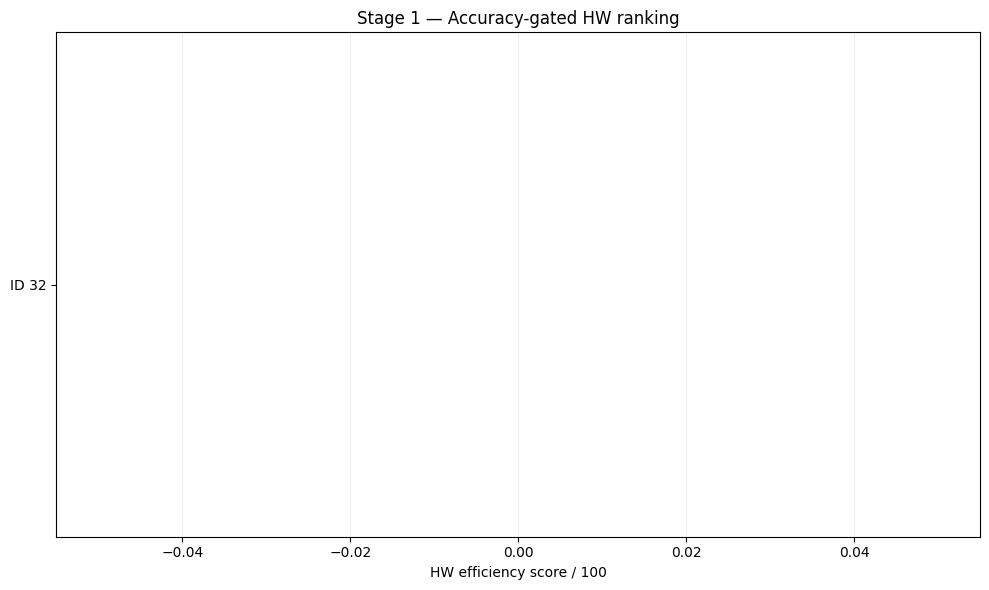

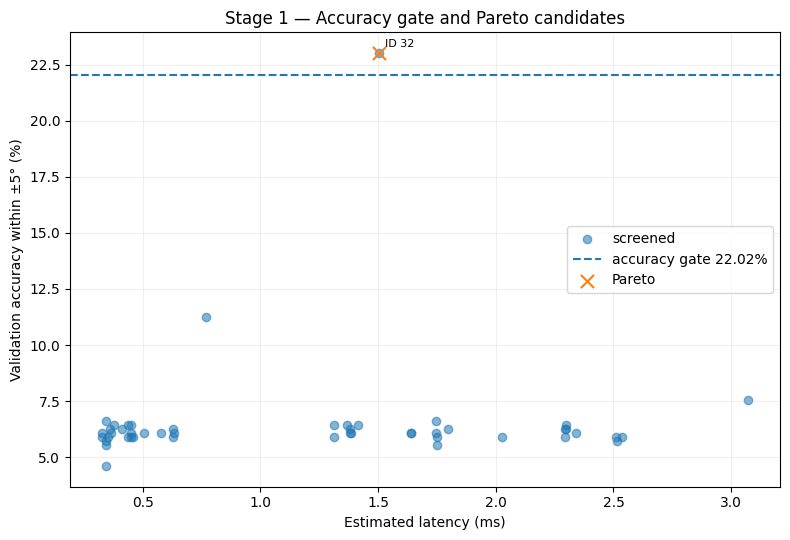

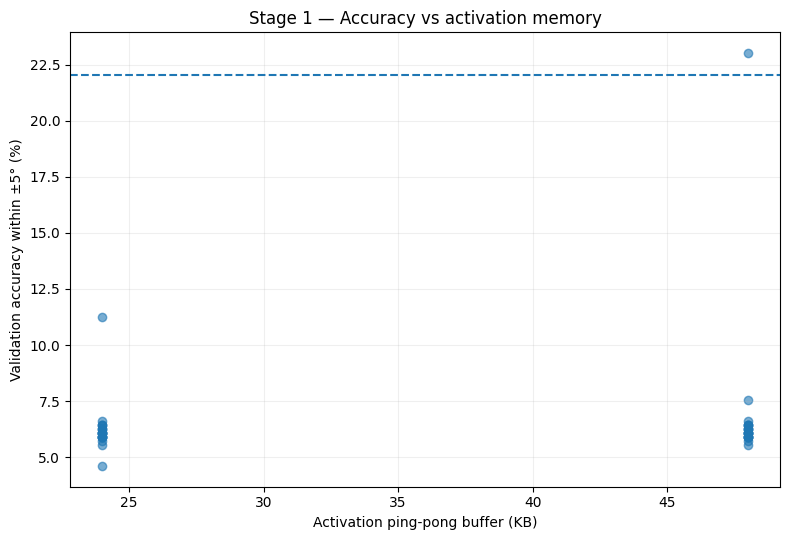


[Stem stride summary]


,stem_stride,models,mean_acc5,median_acc5,mean_latency_ms,mean_pingpong_kb
0,1,25,6.843462,6.077348,1.892215,48.0
1,2,23,6.245496,6.077348,0.448961,24.0



[Max channel summary]


,max_channel,models,mean_acc5,median_acc5,mean_latency_ms,mean_weight_kb
0,4,16,7.090239,6.077348,0.863429,13.492432
1,8,15,6.101903,6.077348,1.137512,25.314453
2,16,17,6.456505,6.077348,1.573761,43.537799


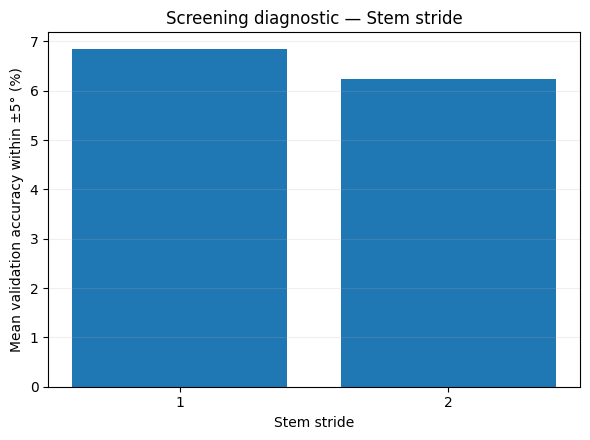

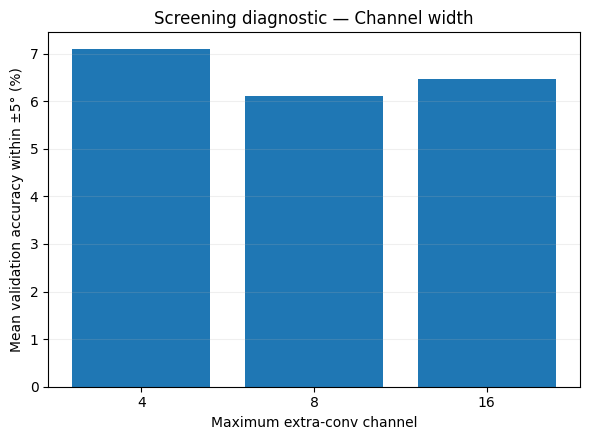

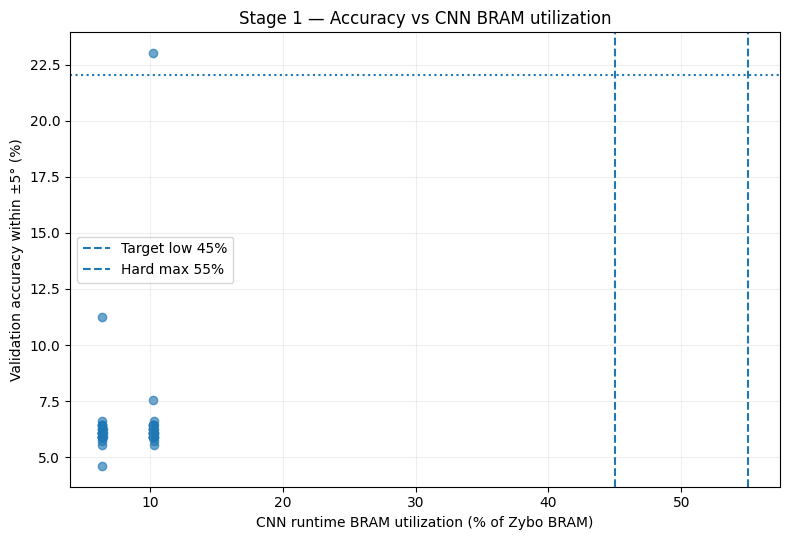

In [49]:

# ============================================================
# 15. Stage 1 comparison plots — Gate / Pareto / structure bias
# ============================================================
eligible_stage1 = screen_ranked[screen_ranked['eligible']].copy()
topn = eligible_stage1.sort_values('hw_score', ascending=False).head(min(15, len(eligible_stage1)))

if len(topn):
    plt.figure(figsize=(10, 6))
    plt.barh([f"ID {int(x)}" for x in topn.id[::-1]], topn.hw_score[::-1])
    plt.xlabel('HW efficiency score / 100')
    plt.title('Stage 1 — Accuracy-gated HW ranking')
    plt.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'stage1_hw_score.png', dpi=170, bbox_inches='tight')
    plt.show()

# Accuracy vs Latency + gate + Pareto
plt.figure(figsize=(8, 5.5))
plt.scatter(screen_ranked['estimated_latency_ms'], screen_ranked['val_acc5'], alpha=0.55, label='screened')
gate_floor = float(screen_ranked['accuracy_gate_floor'].iloc[0])
plt.axhline(gate_floor, linestyle='--', label=f'accuracy gate {gate_floor:.2f}%')

pareto_stage1 = screen_ranked[screen_ranked['pareto']].sort_values('estimated_latency_ms')
if len(pareto_stage1):
    plt.scatter(
        pareto_stage1['estimated_latency_ms'],
        pareto_stage1['val_acc5'],
        s=90,
        marker='x',
        label='Pareto'
    )
    for _, r in pareto_stage1.iterrows():
        plt.annotate(f"ID {int(r.id)}", (r.estimated_latency_ms, r.val_acc5),
                     xytext=(4, 4), textcoords='offset points', fontsize=8)

plt.xlabel('Estimated latency (ms)')
plt.ylabel('Validation accuracy within ±5° (%)')
plt.title('Stage 1 — Accuracy gate and Pareto candidates')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage1_accuracy_latency_pareto.png', dpi=170, bbox_inches='tight')
plt.show()

# Accuracy vs Activation
plt.figure(figsize=(8, 5.5))
plt.scatter(screen_ranked['pingpong_kb'], screen_ranked['val_acc5'], alpha=0.6)
plt.axhline(gate_floor, linestyle='--')
plt.xlabel('Activation ping-pong buffer (KB)')
plt.ylabel('Validation accuracy within ±5° (%)')
plt.title('Stage 1 — Accuracy vs activation memory')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage1_accuracy_activation.png', dpi=170, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# 구조 bias 진단:
# "stride 1 / channel 16이라서 무조건 높게 나오는가?"를 바로 확인
# ------------------------------------------------------------
diag = screen_ranked.copy()
diag['max_channel'] = diag['channels'].apply(_max_channel)

stride_summary = (
    diag.groupby('stem_stride')
        .agg(
            models=('id','count'),
            mean_acc5=('val_acc5','mean'),
            median_acc5=('val_acc5','median'),
            mean_latency_ms=('estimated_latency_ms','mean'),
            mean_pingpong_kb=('pingpong_kb','mean')
        )
        .reset_index()
)
channel_summary = (
    diag.groupby('max_channel')
        .agg(
            models=('id','count'),
            mean_acc5=('val_acc5','mean'),
            median_acc5=('val_acc5','median'),
            mean_latency_ms=('estimated_latency_ms','mean'),
            mean_weight_kb=('int8_weight_kb','mean')
        )
        .reset_index()
)

print('\n[Stem stride summary]')
display(stride_summary)
print('\n[Max channel summary]')
display(channel_summary)

plt.figure(figsize=(6, 4.5))
plt.bar(stride_summary['stem_stride'].astype(str), stride_summary['mean_acc5'])
plt.xlabel('Stem stride')
plt.ylabel('Mean validation accuracy within ±5° (%)')
plt.title('Screening diagnostic — Stem stride')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diag_stem_stride_accuracy.png', dpi=170, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 4.5))
plt.bar(channel_summary['max_channel'].astype(str), channel_summary['mean_acc5'])
plt.xlabel('Maximum extra-conv channel')
plt.ylabel('Mean validation accuracy within ±5° (%)')
plt.title('Screening diagnostic — Channel width')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diag_channel_accuracy.png', dpi=170, bbox_inches='tight')
plt.show()


# Accuracy vs CNN BRAM utilization
plt.figure(figsize=(8, 5.5))
plt.scatter(screen_ranked['bram_util_stream_pct'], screen_ranked['val_acc5'], alpha=0.65)
plt.axvline(45.0, linestyle='--', label='Target low 45%')
plt.axvline(55.0, linestyle='--', label='Hard max 55%')
plt.axhline(gate_floor, linestyle=':')
plt.xlabel('CNN runtime BRAM utilization (% of Zybo BRAM)')
plt.ylabel('Validation accuracy within ±5° (%)')
plt.title('Stage 1 — Accuracy vs CNN BRAM utilization')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'stage1_accuracy_bram_util.png', dpi=170, bbox_inches='tight')
plt.show()


Selected finalists for full training


,id,val_acc5,val_mae_deg,accuracy_gate,eligible,pareto,hw_score,estimated_latency_ms,int8_weight_kb,pingpong_kb,stem_stride,channels,strides,pool_between,head,fc_hidden
0,32,23.020258,14.786876,True,True,True,0.0,1.504948,128.400391,48.0,1,"(4,)","(1,)","(1,)",flatten,"(32,)"
1,34088,11.233886,33.241634,False,False,False,NaN,0.767668,129.033203,24.0,2,"(16,)","(1,)","(1,)",flatten,"(32,)"
2,176,7.550645,41.629069,False,False,False,NaN,3.070530,513.033203,48.0,1,"(16,)","(1,)","(1,)",flatten,"(32,)"
3,37236,6.629834,44.985507,False,False,False,NaN,0.344841,0.712891,24.0,2,"(4, 4, 4)","(1, 2, 2)","(1, 0, 0)",flatten,()
4,18685,6.629834,45.239789,False,False,False,NaN,1.747840,1.845703,48.0,1,"(8, 8, 8)","(2, 2, 1)","(0, 1, 0)",gap,"(16,)"



####################################################################################################
FINAL 1/5 | candidate 32
{'id': np.int64(32), 'stem_stride': np.int64(1), 'n_extra_conv': np.int64(1), 'channels': (4,), 'strides': (1,), 'pool_between': (1,), 'head': 'flatten', 'fc_depth': np.int64(2), 'fc_hidden': (32,)}
[final_id0032] 01/20 loss 0.3380/0.3303 | MAE 45.32/44.88° | Acc±5 5.3/5.9%
[final_id0032] 02/20 loss 0.3097/0.2750 | MAE 43.52/40.63° | Acc±5 6.6/9.8%
[final_id0032] 03/20 loss 0.2133/0.1349 | MAE 35.47/27.62° | Acc±5 9.2/8.1%
[final_id0032] 04/20 loss 0.0583/0.0274 | MAE 16.39/10.98° | Acc±5 21.6/31.9%
[final_id0032] 05/20 loss 0.0171/0.0133 | MAE 8.71/7.65° | Acc±5 39.2/44.8%
[final_id0032] 06/20 loss 0.0093/0.0086 | MAE 6.36/6.27° | Acc±5 51.5/51.9%
[final_id0032] 07/20 loss 0.0060/0.0062 | MAE 5.09/5.07° | Acc±5 60.8/64.1%
[final_id0032] 08/20 loss 0.0045/0.0062 | MAE 4.38/4.96° | Acc±5 68.1/63.9%
[final_id0032] 09/20 loss 0.0038/0.0046 | MAE 4.03/4.38° | Acc±5

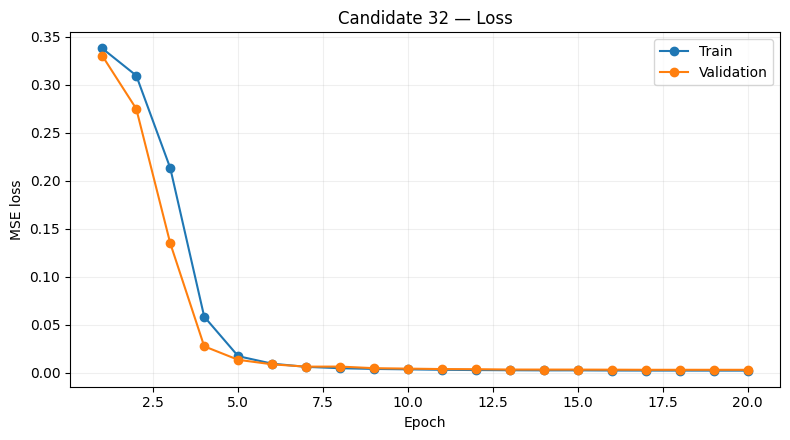

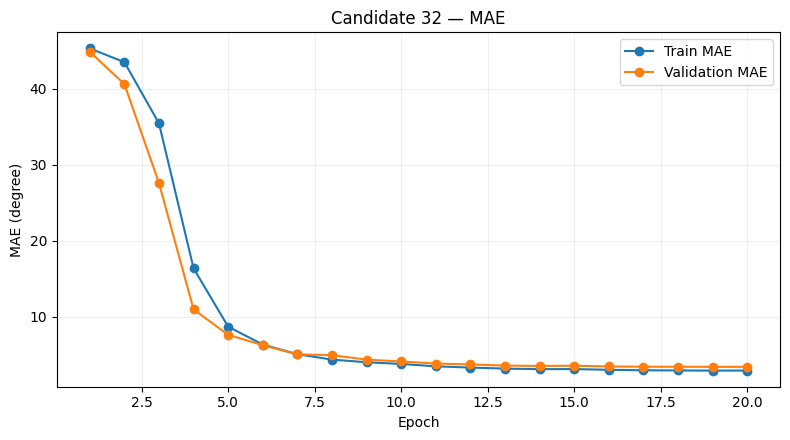

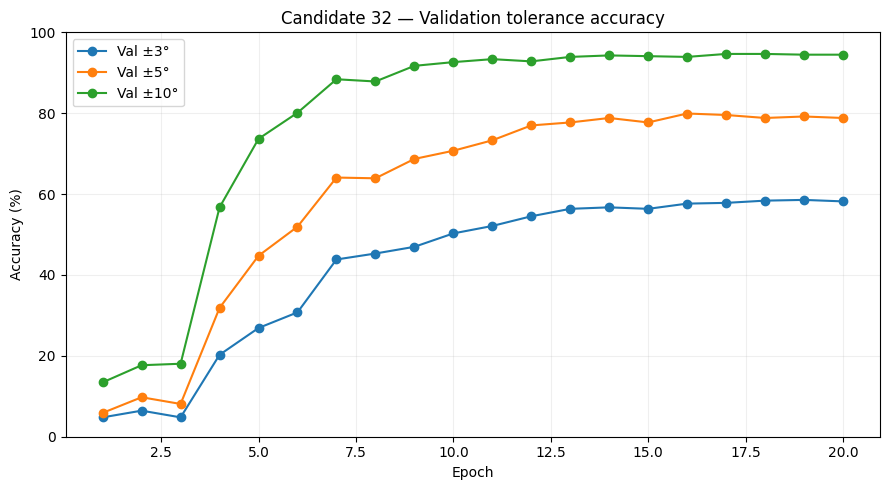


####################################################################################################
FINAL 2/5 | candidate 34088
{'id': np.int64(34088), 'stem_stride': np.int64(2), 'n_extra_conv': np.int64(1), 'channels': (16,), 'strides': (1,), 'pool_between': (1,), 'head': 'flatten', 'fc_depth': np.int64(2), 'fc_hidden': (32,)}
[final_id34088] 01/20 loss 0.3449/0.3376 | MAE 45.61/45.24° | Acc±5 5.3/5.9%
[final_id34088] 02/20 loss 0.3365/0.3376 | MAE 45.22/45.24° | Acc±5 5.4/5.9%
[final_id34088] 03/20 loss 0.3366/0.3376 | MAE 45.22/45.24° | Acc±5 5.4/5.9%
[final_id34088] 04/20 loss 0.3365/0.3376 | MAE 45.22/45.24° | Acc±5 5.4/5.9%
[final_id34088] 05/20 loss 0.3365/0.3376 | MAE 45.22/45.24° | Acc±5 5.4/5.9%
[final_id34088] 06/20 loss 0.3365/0.3376 | MAE 45.22/45.24° | Acc±5 5.4/5.9%
[final_id34088] 07/20 loss 0.3365/0.3376 | MAE 45.22/45.24° | Acc±5 5.4/5.9%
[final_id34088] 08/20 loss 0.3365/0.3376 | MAE 45.22/45.24° | Acc±5 5.3/5.9%
Early stop at epoch 8


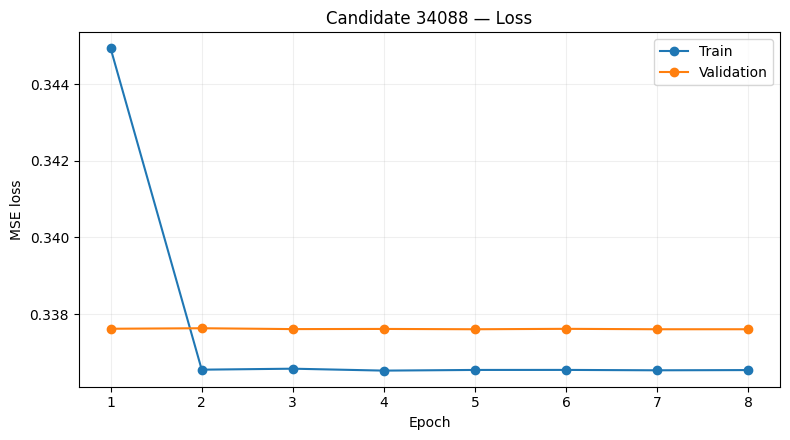

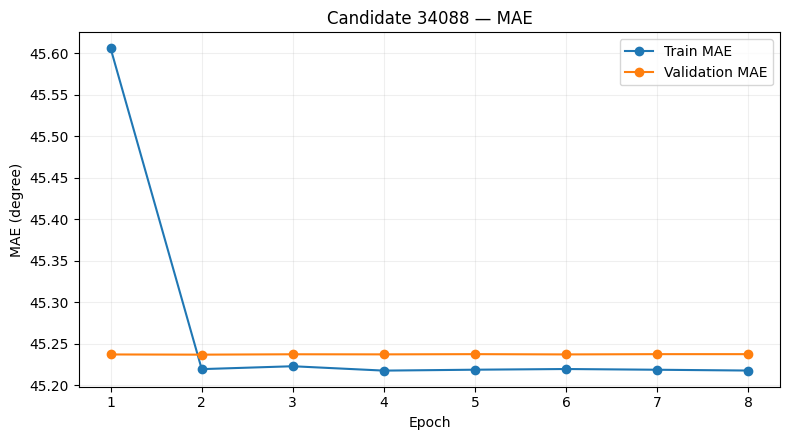

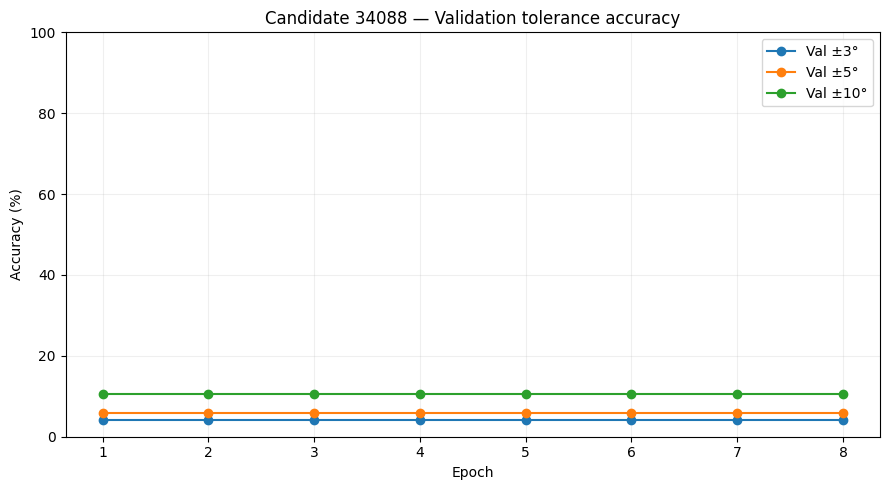


####################################################################################################
FINAL 3/5 | candidate 176
{'id': np.int64(176), 'stem_stride': np.int64(1), 'n_extra_conv': np.int64(1), 'channels': (16,), 'strides': (1,), 'pool_between': (1,), 'head': 'flatten', 'fc_depth': np.int64(2), 'fc_hidden': (32,)}
[final_id0176] 01/20 loss 0.3619/0.3369 | MAE 46.32/45.18° | Acc±5 5.2/6.1%
[final_id0176] 02/20 loss 0.3338/0.3371 | MAE 45.11/45.21° | Acc±5 5.2/6.4%
[final_id0176] 03/20 loss 0.3308/0.3300 | MAE 44.94/44.94° | Acc±5 5.4/6.1%
[final_id0176] 04/20 loss 0.3198/0.3191 | MAE 44.45/44.34° | Acc±5 6.4/8.1%
[final_id0176] 05/20 loss 0.3009/0.2893 | MAE 43.36/42.29° | Acc±5 7.1/7.9%
[final_id0176] 06/20 loss 0.2411/0.1927 | MAE 38.47/34.19° | Acc±5 9.7/10.1%
[final_id0176] 07/20 loss 0.1187/0.0672 | MAE 25.97/19.02° | Acc±5 11.3/14.5%
[final_id0176] 08/20 loss 0.0313/0.0233 | MAE 12.32/10.44° | Acc±5 25.5/32.0%
[final_id0176] 09/20 loss 0.0181/0.0167 | MAE 9.29/8.72° |

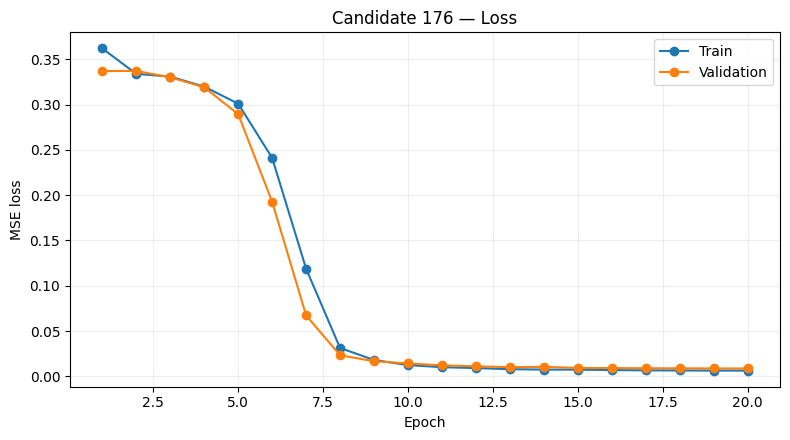

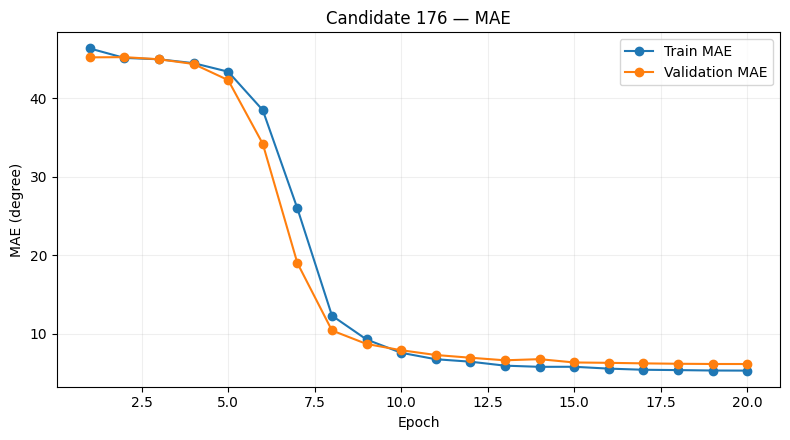

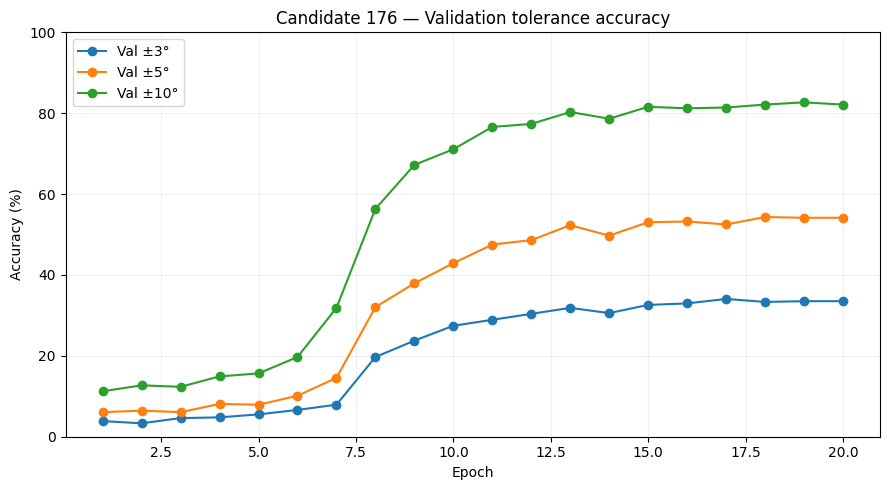


####################################################################################################
FINAL 4/5 | candidate 37236
{'id': np.int64(37236), 'stem_stride': np.int64(2), 'n_extra_conv': np.int64(3), 'channels': (4, 4, 4), 'strides': (1, 2, 2), 'pool_between': (1, 0, 0), 'head': 'flatten', 'fc_depth': np.int64(1), 'fc_hidden': ()}
[final_id37236] 01/20 loss 0.3391/0.3367 | MAE 45.29/45.17° | Acc±5 5.7/6.4%
[final_id37236] 02/20 loss 0.3346/0.3341 | MAE 45.07/44.93° | Acc±5 5.5/5.9%
[final_id37236] 03/20 loss 0.3297/0.3243 | MAE 44.66/44.14° | Acc±5 5.6/6.1%
[final_id37236] 04/20 loss 0.3049/0.2673 | MAE 42.66/39.45° | Acc±5 6.2/6.3%
[final_id37236] 05/20 loss 0.1920/0.0943 | MAE 32.18/21.30° | Acc±5 10.5/14.5%
[final_id37236] 06/20 loss 0.0542/0.0365 | MAE 16.05/13.25° | Acc±5 21.6/23.8%
[final_id37236] 07/20 loss 0.0255/0.0231 | MAE 10.82/10.37° | Acc±5 31.3/33.0%
[final_id37236] 08/20 loss 0.0189/0.0172 | MAE 9.45/8.94° | Acc±5 34.7/36.3%
[final_id37236] 09/20 loss 0.0155/

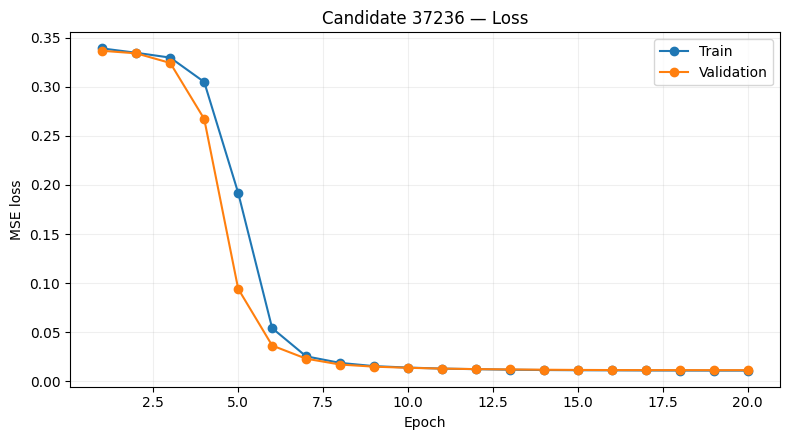

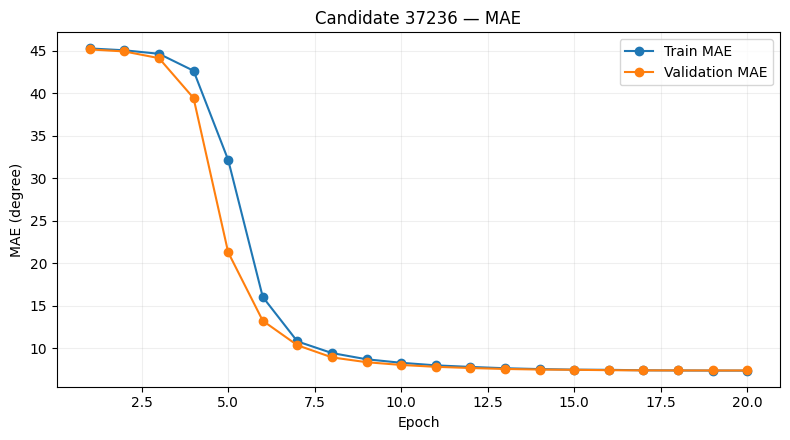

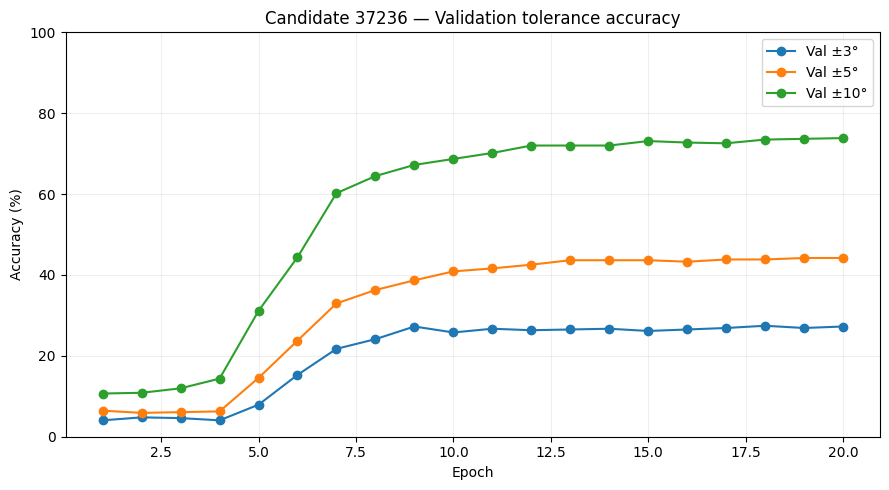


####################################################################################################
FINAL 5/5 | candidate 18685
{'id': np.int64(18685), 'stem_stride': np.int64(1), 'n_extra_conv': np.int64(3), 'channels': (8, 8, 8), 'strides': (2, 2, 1), 'pool_between': (0, 1, 0), 'head': 'gap', 'fc_depth': np.int64(2), 'fc_hidden': (16,)}
[final_id18685] 01/20 loss 0.3406/0.3381 | MAE 45.40/45.25° | Acc±5 5.4/6.3%
[final_id18685] 02/20 loss 0.3366/0.3378 | MAE 45.22/45.23° | Acc±5 5.4/6.3%
[final_id18685] 03/20 loss 0.3369/0.3378 | MAE 45.24/45.23° | Acc±5 5.3/6.3%
[final_id18685] 04/20 loss 0.3368/0.3378 | MAE 45.23/45.24° | Acc±5 5.5/6.3%
[final_id18685] 05/20 loss 0.3366/0.3379 | MAE 45.22/45.24° | Acc±5 5.1/5.7%
[final_id18685] 06/20 loss 0.3368/0.3378 | MAE 45.23/45.23° | Acc±5 5.4/6.3%
[final_id18685] 07/20 loss 0.3367/0.3378 | MAE 45.24/45.23° | Acc±5 5.1/6.3%
[final_id18685] 08/20 loss 0.3367/0.3378 | MAE 45.23/45.23° | Acc±5 5.5/5.9%
[final_id18685] 09/20 loss 0.3365/0.3378 

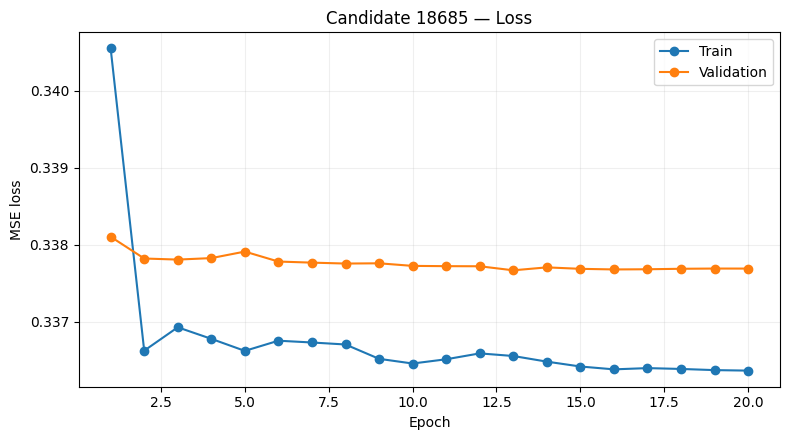

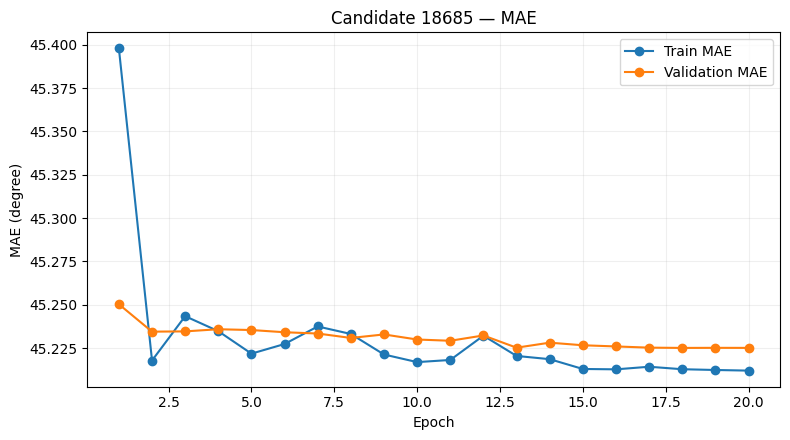

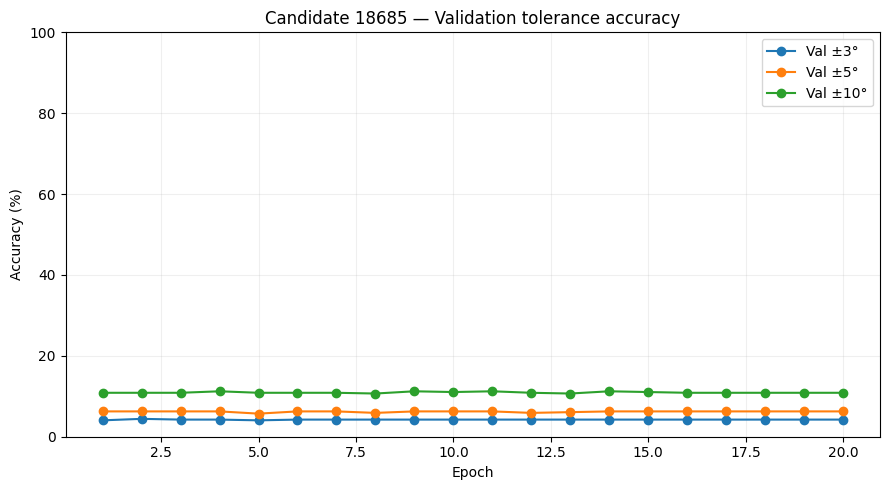

Accuracy champion ID : 32
HW-selected RTL ID   : 32
Same model?          : True


,id,selected_for_rtl,accuracy_champion,val_acc3,val_acc5,val_acc10,val_mae_deg,val_r2,accuracy_gap_pp,accuracy_gate,...,BRAM_IN_TARGET_45_55_STREAM,HW_OK_STREAM,HW_OK_ALL_WEIGHTS,hw_score,stem_stride,channels,strides,pool_between,head,fc_hidden
0,32,True,True,58.195212,78.821363,94.475138,3.426848,0.991457,0.000000,True,...,False,True,True,0.0,1,"(4,)","(1,)","(1,)",flatten,"(32,)"
1,176,False,False,33.517495,54.143646,82.136280,6.169719,0.974182,24.677716,False,...,False,True,False,NaN,1,"(16,)","(1,)","(1,)",flatten,"(32,)"
2,37236,False,False,27.255985,44.198895,73.848987,7.396597,0.966078,34.622468,False,...,False,True,True,NaN,2,"(4, 4, 4)","(1, 2, 2)","(1, 0, 0)",flatten,()
3,18685,False,False,4.235727,6.261510,10.865562,45.225155,-0.000263,72.559853,False,...,False,True,True,NaN,1,"(8, 8, 8)","(2, 2, 1)","(0, 1, 0)",gap,"(16,)"
4,34088,False,False,4.235727,5.893186,10.681400,45.236847,-0.000088,72.928177,False,...,False,True,True,NaN,2,"(16,)","(1,)","(1,)",flatten,"(32,)"


In [50]:

# ============================================================
# 16. Stage 2 — Full training of diverse finalists
# ============================================================
finalist_seed = select_diverse_finalists(screen_ranked, TOP_K_FINALISTS)

print('Selected finalists for full training')
display(finalist_seed[[
    'id','val_acc5','val_mae_deg','accuracy_gate','eligible','pareto',
    'hw_score','estimated_latency_ms','int8_weight_kb','pingpong_kb',
    'stem_stride','channels','strides','pool_between','head','fc_hidden'
]])

finalist_seed.to_csv(OUTPUT_DIR / 'stage2_finalist_seed.csv', index=False)

final_results = []
final_histories = {}

for rank_idx, row in finalist_seed.iterrows():
    original_row = candidates_hw[candidates_hw.id == int(row.id)].iloc[0]
    cfg = config_from_row(original_row)
    cid = int(cfg['id'])

    print('\n' + '#' * 100)
    print(f'FINAL {rank_idx+1}/{len(finalist_seed)} | candidate {cid}')
    print(cfg)

    model, hist, val = train_one_candidate(
        cfg,
        epochs=FINAL_EPOCHS,
        run_name=f'final_id{cid:04d}',
        save_best=True,
        patience=EARLY_STOP_PATIENCE,
    )
    final_histories[cid] = hist
    plot_history(hist, f'Candidate {cid}', OUTPUT_DIR / f'final_id{cid:04d}.png')

    result = original_row.to_dict()
    result.update({
        'val_loss': val['loss'],
        'val_mae_deg': val['mae_deg'],
        'val_acc3': val['acc3'],
        'val_acc5': val['acc5'],
        'val_acc10': val['acc10'],
        'val_r2': val['r2'],
    })
    final_results.append(result)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

final_results_df = pd.DataFrame(final_results)
final_ranked = add_selection_metrics(final_results_df)

# 최종 선택 후보: gate 통과 모델 중 HW score 최고
eligible_final = final_ranked[final_ranked['eligible']].copy()
if len(eligible_final):
    selected_id = int(eligible_final.sort_values('hw_score', ascending=False).iloc[0].id)
else:
    # 안전 fallback
    selected_id = int(final_ranked.sort_values('val_acc5', ascending=False).iloc[0].id)

accuracy_champion_id = int(final_ranked.sort_values('val_acc5', ascending=False).iloc[0].id)

final_ranked['selected_for_rtl'] = final_ranked['id'].astype(int) == selected_id
final_ranked['accuracy_champion'] = final_ranked['id'].astype(int) == accuracy_champion_id

# selected가 맨 위, 그 다음 eligible + hw score
final_ranked = final_ranked.sort_values(
    ['selected_for_rtl','eligible','hw_score','val_acc5'],
    ascending=[False,False,False,False],
    na_position='last'
).reset_index(drop=True)

final_ranked.to_csv(OUTPUT_DIR / 'FINAL_RANKING.csv', index=False)

print('Accuracy champion ID :', accuracy_champion_id)
print('HW-selected RTL ID   :', selected_id)
print('Same model?          :', accuracy_champion_id == selected_id)

display(final_ranked[[
    'id','selected_for_rtl','accuracy_champion',
    'val_acc3','val_acc5','val_acc10','val_mae_deg','val_r2',
    'accuracy_gap_pp','accuracy_gate','mae_gate','eligible','pareto',
    'estimated_latency_ms','int8_weight_kb','pingpong_kb','line_buffer_kb','macs_m',
    'runtime_bram_stream_kb','bram_util_stream_pct','BRAM_IN_TARGET_45_55_STREAM','HW_OK_STREAM','HW_OK_ALL_WEIGHTS','hw_score',
    'stem_stride','channels','strides','pool_between','head','fc_hidden'
]])


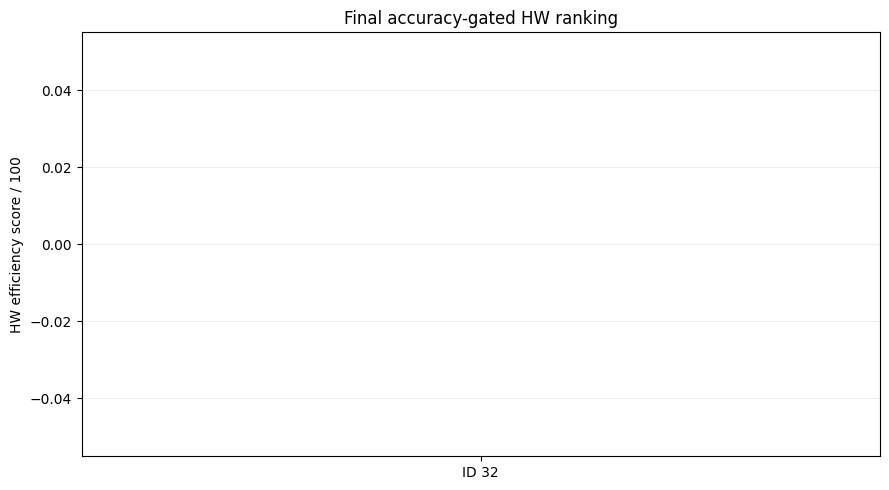

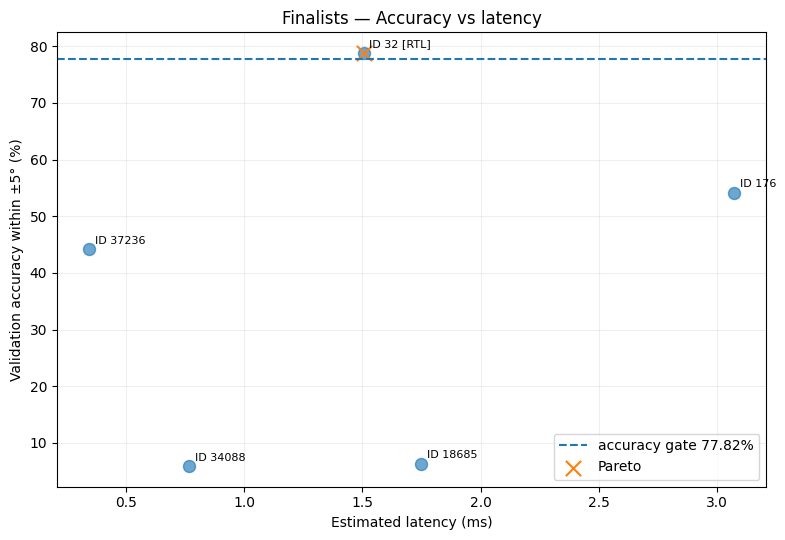

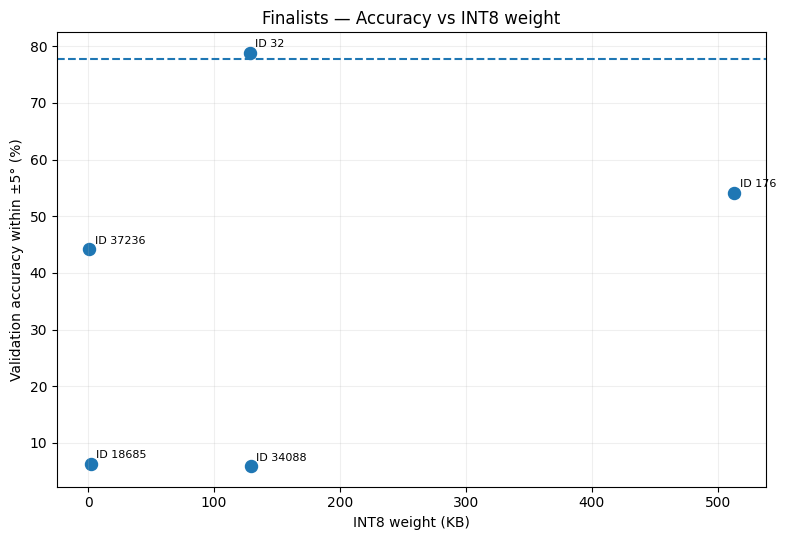

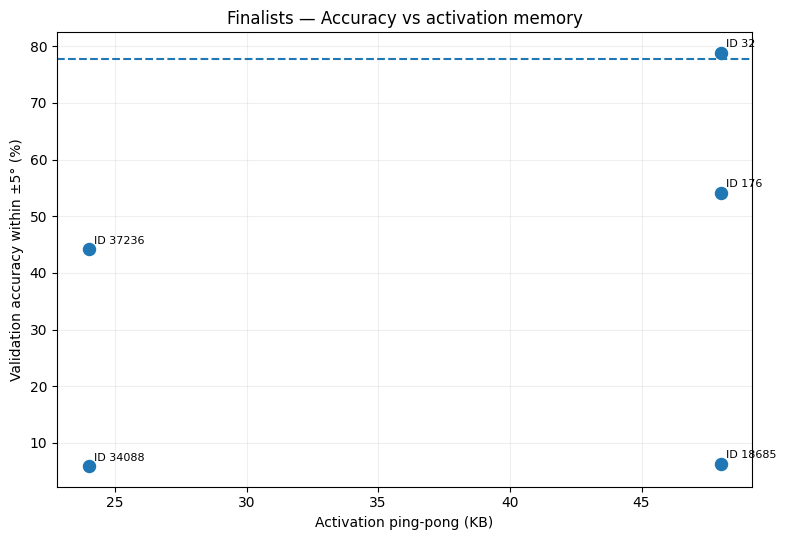


[Final Pareto candidates]


,id,selected_for_rtl,accuracy_champion,val_acc5,val_mae_deg,estimated_latency_ms,int8_weight_kb,pingpong_kb,hw_score,channels,strides,pool_between,head
0,32,True,True,78.821363,3.426848,1.504948,128.400391,48.0,0.0,"(4,)","(1,)","(1,)",flatten


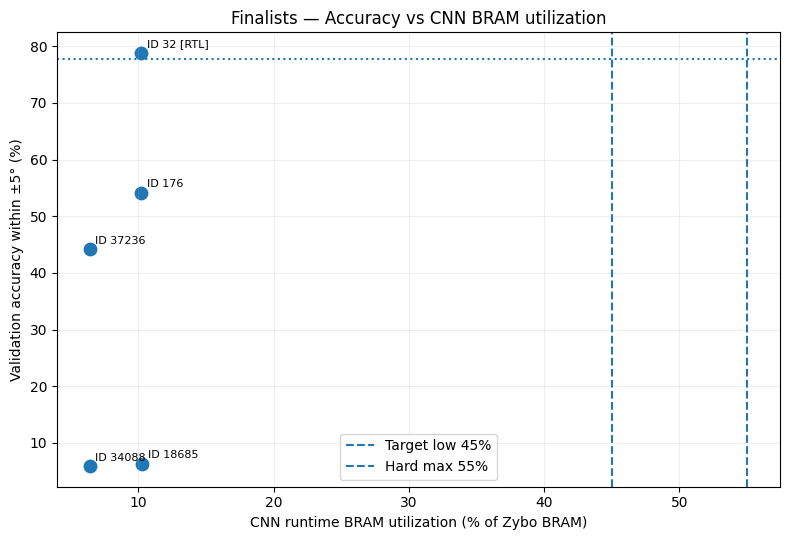

In [51]:

# ============================================================
# 17. Final ranking / Pareto plots
# ============================================================
plot_df = final_ranked.copy()
eligible_plot = plot_df[plot_df['eligible']].sort_values('hw_score', ascending=False)

if len(eligible_plot):
    plt.figure(figsize=(9, 5))
    plt.bar([f'ID {int(i)}' for i in eligible_plot.id], eligible_plot.hw_score)
    plt.ylabel('HW efficiency score / 100')
    plt.title('Final accuracy-gated HW ranking')
    plt.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'final_hw_ranking.png', dpi=170, bbox_inches='tight')
    plt.show()

gate_floor = float(plot_df['accuracy_gate_floor'].iloc[0])

# Accuracy vs latency
plt.figure(figsize=(8, 5.5))
plt.scatter(plot_df['estimated_latency_ms'], plot_df['val_acc5'], s=75, alpha=0.65)
plt.axhline(gate_floor, linestyle='--', label=f'accuracy gate {gate_floor:.2f}%')

p = plot_df[plot_df['pareto']].sort_values('estimated_latency_ms')
if len(p):
    plt.scatter(p['estimated_latency_ms'], p['val_acc5'], s=120, marker='x', label='Pareto')

for _, r in plot_df.iterrows():
    label = f"ID {int(r.id)}"
    if bool(r.selected_for_rtl):
        label += " [RTL]"
    elif bool(r.accuracy_champion):
        label += " [ACC]"
    plt.annotate(label, (r.estimated_latency_ms, r.val_acc5),
                 xytext=(4,4), textcoords='offset points', fontsize=8)

plt.xlabel('Estimated latency (ms)')
plt.ylabel('Validation accuracy within ±5° (%)')
plt.title('Finalists — Accuracy vs latency')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'final_accuracy_latency_pareto.png', dpi=170, bbox_inches='tight')
plt.show()

# Accuracy vs INT8 weight
plt.figure(figsize=(8, 5.5))
plt.scatter(plot_df['int8_weight_kb'], plot_df['val_acc5'], s=75)
plt.axhline(gate_floor, linestyle='--')
for _, r in plot_df.iterrows():
    plt.annotate(f"ID {int(r.id)}", (r.int8_weight_kb, r.val_acc5),
                 xytext=(4,4), textcoords='offset points', fontsize=8)
plt.xlabel('INT8 weight (KB)')
plt.ylabel('Validation accuracy within ±5° (%)')
plt.title('Finalists — Accuracy vs INT8 weight')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'final_accuracy_weight.png', dpi=170, bbox_inches='tight')
plt.show()

# Accuracy vs activation ping-pong
plt.figure(figsize=(8, 5.5))
plt.scatter(plot_df['pingpong_kb'], plot_df['val_acc5'], s=75)
plt.axhline(gate_floor, linestyle='--')
for _, r in plot_df.iterrows():
    plt.annotate(f"ID {int(r.id)}", (r.pingpong_kb, r.val_acc5),
                 xytext=(4,4), textcoords='offset points', fontsize=8)
plt.xlabel('Activation ping-pong (KB)')
plt.ylabel('Validation accuracy within ±5° (%)')
plt.title('Finalists — Accuracy vs activation memory')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'final_accuracy_activation.png', dpi=170, bbox_inches='tight')
plt.show()

# Pareto 후보 표
print('\n[Final Pareto candidates]')
display(
    plot_df[plot_df['pareto']][[
        'id','selected_for_rtl','accuracy_champion',
        'val_acc5','val_mae_deg','estimated_latency_ms',
        'int8_weight_kb','pingpong_kb','hw_score',
        'channels','strides','pool_between','head'
    ]].sort_values('estimated_latency_ms')
)


# Accuracy vs BRAM utilization
plt.figure(figsize=(8, 5.5))
plt.scatter(plot_df['bram_util_stream_pct'], plot_df['val_acc5'], s=80)
plt.axvline(45.0, linestyle='--', label='Target low 45%')
plt.axvline(55.0, linestyle='--', label='Hard max 55%')
plt.axhline(gate_floor, linestyle=':')

for _, r in plot_df.iterrows():
    label = f"ID {int(r.id)}"
    if bool(r.selected_for_rtl):
        label += " [RTL]"
    plt.annotate(label, (r.bram_util_stream_pct, r.val_acc5),
                 xytext=(4,4), textcoords='offset points', fontsize=8)

plt.xlabel('CNN runtime BRAM utilization (% of Zybo BRAM)')
plt.ylabel('Validation accuracy within ±5° (%)')
plt.title('Finalists — Accuracy vs CNN BRAM utilization')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'final_accuracy_bram_util.png', dpi=170, bbox_inches='tight')
plt.show()


In [52]:

# ============================================================
# 18. Test evaluation — ONLY the selected RTL architecture
# ============================================================
selected = final_ranked[final_ranked['selected_for_rtl']].iloc[0]
best = selected  # 뒤 diagnostic cell 호환용 alias
best_id = int(selected.id)

orig = candidates_hw[candidates_hw.id == best_id].iloc[0]
best_cfg = config_from_row(orig)

ckpt_path = OUTPUT_DIR / f'final_id{best_id:04d}_best.pt'

best_model = CandidateCNN(best_cfg).to(DEVICE)
state_dict = load_model_state_dict_compat(
    ckpt_path,
    map_location=DEVICE,
)
best_model.load_state_dict(state_dict)

criterion = nn.MSELoss()
test_metrics = evaluate(best_model, test_loader, criterion)

print('SELECTED RTL ARCHITECTURE ID:', best_id)
print('Config:', best_cfg)
print('\nTest metrics')
print('  MSE loss : %.6f' % test_metrics['loss'])
print('  MAE      : %.3f deg' % test_metrics['mae_deg'])
print('  Acc ±3°  : %.2f %%' % test_metrics['acc3'])
print('  Acc ±5°  : %.2f %%' % test_metrics['acc5'])
print('  Acc ±10° : %.2f %%' % test_metrics['acc10'])
print('  R²       : %.4f' % test_metrics['r2'])

best_summary = {
    'selected_rtl_id': best_id,
    'accuracy_champion_id': int(final_ranked[final_ranked['accuracy_champion']].iloc[0].id),
    'config': best_cfg,
    'selection_rule': {
        'accuracy_tolerance_pp': ACCURACY_TOLERANCE_PP,
        'mae_tolerance_deg': MAE_TOLERANCE_DEG,
        'enforce_mae_gate': ENFORCE_MAE_GATE,
        'hw_score_weights': HW_SCORE_WEIGHTS,
        'bram_target_low_fraction': BRAM_TARGET_LOW_FRACTION,
        'bram_hard_max_fraction': BRAM_HARD_MAX_FRACTION,
    },
    'validation': {
        k: float(selected[k]) for k in [
            'val_loss','val_mae_deg','val_acc3','val_acc5','val_acc10','val_r2','hw_score'
        ]
    },
    'test': {
        k: float(test_metrics[k]) for k in ['loss','mae_deg','acc3','acc5','acc10','r2']
    },
    'hardware': {
        k: float(selected[k]) if isinstance(selected[k], (int,float,np.number)) else selected[k]
        for k in [
            'macs_m','int8_weight_kb','pingpong_kb','line_buffer_kb',
            'runtime_bram_stream_kb','bram_util_stream_pct','estimated_latency_ms'
        ]
    },
}

with open(OUTPUT_DIR / 'best_model_summary.json', 'w', encoding='utf-8') as f:
    json.dump(best_summary, f, ensure_ascii=False, indent=2, default=str)


SELECTED RTL ARCHITECTURE ID: 32
Config: {'id': np.int64(32), 'stem_stride': np.int64(1), 'n_extra_conv': np.int64(1), 'channels': (4,), 'strides': (1,), 'pool_between': (1,), 'head': 'flatten', 'fc_depth': np.int64(2), 'fc_hidden': (32,)}

Test metrics
  MSE loss : 0.002798
  MAE      : 3.498 deg
  Acc ±3°  : 55.88 %
  Acc ±5°  : 75.92 %
  Acc ±10° : 95.04 %
  R²       : 0.9917


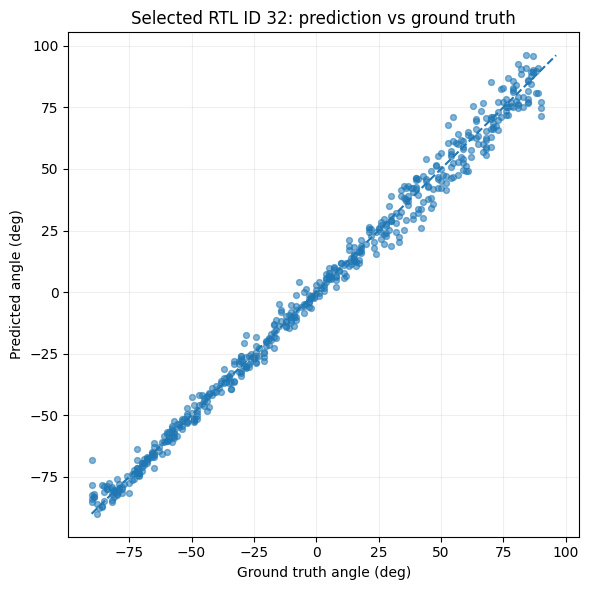

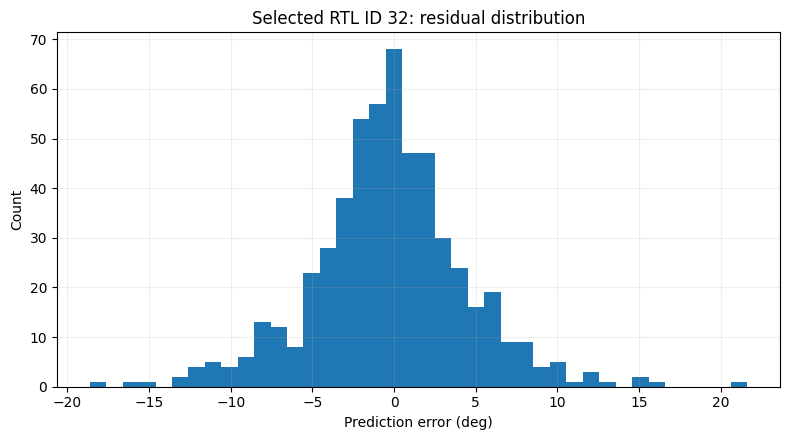

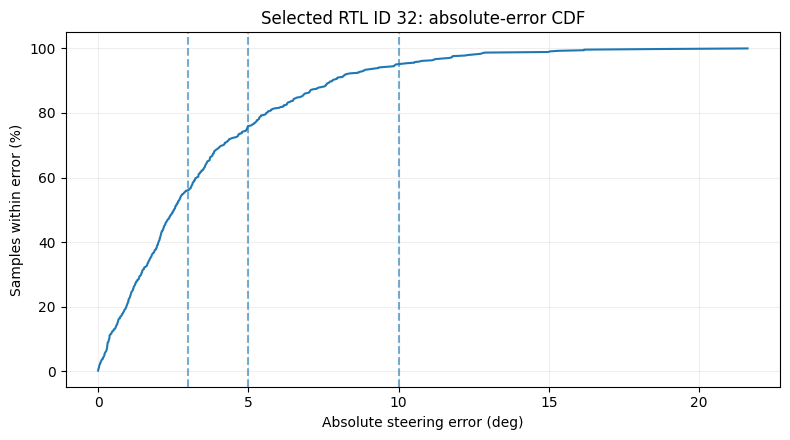

In [53]:
# ============================================================
# 19. Selected RTL model diagnostic plots
# ============================================================
pred = test_metrics['pred_deg']
tgt = test_metrics['target_deg']
err = pred - tgt

# GT vs Prediction
plt.figure(figsize=(6, 6))
plt.scatter(tgt, pred, alpha=0.55, s=18)
lo = min(tgt.min(), pred.min()); hi = max(tgt.max(), pred.max())
plt.plot([lo, hi], [lo, hi], linestyle='--')
plt.xlabel('Ground truth angle (deg)')
plt.ylabel('Predicted angle (deg)')
plt.title(f'Selected RTL ID {best_id}: prediction vs ground truth')
plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'selected_prediction_vs_gt.png', dpi=170, bbox_inches='tight')
plt.show()

# Residual histogram
plt.figure(figsize=(8, 4.5))
plt.hist(err, bins=40)
plt.xlabel('Prediction error (deg)')
plt.ylabel('Count')
plt.title(f'Selected RTL ID {best_id}: residual distribution')
plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'selected_residual_hist.png', dpi=170, bbox_inches='tight')
plt.show()

# Absolute error CDF
abs_err = np.abs(err)
xs = np.sort(abs_err)
ys = np.arange(1, len(xs)+1) / len(xs) * 100
plt.figure(figsize=(8, 4.5))
plt.plot(xs, ys)
for tol in [3,5,10]:
    plt.axvline(tol, linestyle='--', alpha=0.6)
plt.xlabel('Absolute steering error (deg)')
plt.ylabel('Samples within error (%)')
plt.title(f'Selected RTL ID {best_id}: absolute-error CDF')
plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'selected_abs_error_cdf.png', dpi=170, bbox_inches='tight')
plt.show()


In [54]:

# ============================================================
# 20. Human-readable final report
# ============================================================
rtl = final_ranked[final_ranked['selected_for_rtl']].iloc[0]
acc = final_ranked[final_ranked['accuracy_champion']].iloc[0]

print('='*96)
print('FINAL ARCHITECTURE DECISION SUPPORT')
print('='*96)

print('\n[1] Accuracy champion')
print(f"ID                  : {int(acc.id)}")
print(f"Val Acc ±5°         : {acc.val_acc5:.2f}%")
print(f"Val MAE             : {acc.val_mae_deg:.3f}°")
print(f"Est. latency        : {acc.estimated_latency_ms:.4f} ms")
print(f"INT8 Weight         : {acc.int8_weight_kb:.2f} KB")
print(f"Activation pingpong : {acc.pingpong_kb:.2f} KB")

print('\n[2] Accuracy-gated HW-selected RTL candidate')
print(f"ID                  : {int(rtl.id)}")
print(f"Stem stride         : {int(rtl.stem_stride)}")
print(f"Extra channels      : {rtl.channels}")
print(f"Extra strides       : {rtl.strides}")
print(f"Pool between convs  : {rtl.pool_between}")
print(f"Head                : {rtl.head}")
print(f"FC hidden           : {rtl.fc_hidden}")
print('-'*96)
print(f"Val Acc ±5°         : {rtl.val_acc5:.2f}%")
print(f"Accuracy gap        : {rtl.accuracy_gap_pp:.3f}%p from best")
print(f"Val MAE             : {rtl.val_mae_deg:.3f}°")
print(f"Accuracy gate       : {bool(rtl.accuracy_gate)}")
print(f"MAE gate            : {bool(rtl.mae_gate)}")
print(f"Pareto candidate    : {bool(rtl.pareto)}")
print('-'*96)
print(f"INT8 Weight         : {rtl.int8_weight_kb:.2f} KB")
print(f"Activation pingpong : {rtl.pingpong_kb:.2f} KB")
print(f"Line buffer         : {rtl.line_buffer_kb:.2f} KB")
print(f"MACs                : {rtl.macs_m:.3f} M  (latency 계산용, score 중복 반영 X)")
print(f"Est. latency        : {rtl.estimated_latency_ms:.4f} ms")
print(f"Runtime BRAM(stream): {rtl.runtime_bram_stream_kb:.2f} KB")
print(f"BRAM utilization    : {rtl.bram_util_stream_pct:.2f}% of total Zybo BRAM")
print(f"BRAM target 45~55%  : {bool(rtl.BRAM_IN_TARGET_45_55_STREAM)}")
print(f"BRAM hard max       : {CNN_BRAM_BUDGET_BYTES/1024:.1f} KB = 55%")
print(f"All weights on BRAM : {bool(rtl.HW_OK_ALL_WEIGHTS)}")
print(f"HW score            : {rtl.hw_score:.2f}/100")
print('-'*96)
print('Shape trace:')
print(rtl.shape_trace)

print('\n[3] Final Pareto IDs')
print(final_ranked.loc[final_ranked['pareto'], 'id'].astype(int).tolist())

if int(acc.id) != int(rtl.id):
    print('\nAccuracy champion과 RTL-selected 모델이 다릅니다.')
    print('이것은 오류가 아니라, 허용 정확도 범위 안에서 더 작은 HW 구조를 고른 결과입니다.')
else:
    print('\nAccuracy champion과 RTL-selected 모델이 동일합니다.')


FINAL ARCHITECTURE DECISION SUPPORT

[1] Accuracy champion
ID                  : 32
Val Acc ±5°         : 78.82%
Val MAE             : 3.427°
Est. latency        : 1.5049 ms
INT8 Weight         : 128.40 KB
Activation pingpong : 48.00 KB

[2] Accuracy-gated HW-selected RTL candidate
ID                  : 32
Stem stride         : 1
Extra channels      : (4,)
Extra strides       : (1,)
Pool between convs  : (1,)
Head                : <bound method NDFrame.head of id                                                                                 32
stem_stride                                                                         1
n_extra_conv                                                                        1
channels                                                                         (4,)
strides                                                                          (1,)
pool_between                                                                     (1,)
head               


## 해석 시 주의사항

1. **CNN BRAM은 전체 Zybo BRAM의 55%를 절대 상한으로 사용합니다.** 45~55%는 목표 구간이며, 45% 미만 후보는 더 여유 있는 정상 후보로 유지합니다.
2. **Accuracy가 HW Score에 직접 들어가지 않습니다.** 대신 최고 Validation ±5° Accuracy에서 `ACCURACY_TOLERANCE_PP` 이내인 후보만 HW 효율 비교 대상이 됩니다.
3. 기본값은 `Best Acc - 1.0%p` Accuracy Gate와 `Best gated MAE + 0.5°` MAE Gate입니다. 프로젝트 요구 정확도에 맞춰 Config cell에서 바꿀 수 있습니다.
4. HW Score는 `Latency 50% + Activation 25% + INT8 Weight 15% + MAE 10%`입니다.
5. **MACs는 Estimated Latency 계산에 이미 포함**되므로 별도 점수로 다시 넣지 않아 이중 패널티를 피했습니다.
6. Screening candidate는 stem stride / channel scale / head / conv depth가 최대한 균등하게 섞이도록 선택합니다. 따라서 channel=16, stride=1 후보가 단순히 많이 뽑혀 유리해지는 편향을 줄였습니다.
7. `Pareto=True`는 Validation Accuracy를 높이면서 Latency / Activation / Weight / MAE를 동시에 낮추는 관점에서 다른 후보에 완전히 지배되지 않는 구조입니다.
8. Architecture search 학습 자체는 **FP32 baseline**이지만, v7에서는 finalist마다 실제 **signed INT8 PTQ + integer reference inference**를 수행하고 INT8 validation 결과로 최종 RTL 후보를 다시 선택합니다.
9. `estimated_latency_ms`는 **3×3 PE Array = 9 MAC/cycle, 100 MHz, 75% effective utilization**을 가정한 1차 추정입니다. RTL 이후에는 FIFO stall, weight loading, pipeline fill/drain, DMA/DDR latency를 추가해야 합니다.
10. Test set은 최종 선택된 RTL 후보에만 사용하여 architecture search 중 test leakage를 방지합니다.

11. **PyTorch 2.6+ checkpoint 호환:** 새 체크포인트는 `state_dict`만 저장하여 `weights_only=True`로 읽습니다. v4에서 이미 생성한 `{config, state_dict}` 형식의 체크포인트도 호환 로더가 읽을 수 있습니다.

12. INT8 PTQ는 **per-tensor symmetric scale, zero-point=0** 기준입니다. RTL 단순화를 우선한 설정이며, 이후 정확도가 부족하면 per-channel weight quantization 또는 QAT를 추가할 수 있습니다.


# 22. REAL Signed INT8 PTQ — RTL Golden Reference

이제부터는 HW 비용을 INT8이라고 **가정만** 하는 것이 아니라, finalist checkpoint의 실제 FP32 weight/activation을 signed INT8로 양자화하여 integer 연산을 수행합니다.

### 양자화 규칙

\[
q = \mathrm{clip}\left(\mathrm{round}_{away}(x/S), -127, 127\right)
\]

- `zero_point = 0`
- Weight/Activation 모두 symmetric signed INT8
- Conv/FC: `INT8 × INT8 → INT32 accumulate`
- Bias: `bias_q = round(bias / (S_in × S_w))`, INT32
- Hidden output: `INT32 → fixed-point requantization → INT8`
- ReLU layer는 requantization 뒤 `0..127` 범위
- 최종 regression output은 다음 layer로 넘길 activation이 아니므로 **INT32 accumulator + scale** 형태를 유지합니다. 즉 최종 angle 정밀도를 불필요하게 INT8 256단계로 제한하지 않습니다.

Calibration에는 train split만 사용하고, finalist 선택에는 validation split만 사용하며, test split은 최종 INT8 RTL 후보 한 개에만 사용합니다.

In [55]:
# ============================================================
# 22-1. INT8 PTQ Config
# ============================================================
import torch.nn.functional as F

INT8_QMIN = -127          # symmetric signed INT8; -128은 사용하지 않음
INT8_QMAX = 127
INT8_ZERO_POINT = 0
PTQ_CALIB_BATCHES = None  # None = full train split calibration
PTQ_CALIB_BATCH_SIZE = BATCH_SIZE
MAX_FIXED_SHIFT = 30      # layer별 requant multiplier의 fractional shift 상한

INT8_EXPORT_DIR = OUTPUT_DIR / 'int8_rtl_export'
INT8_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Calibration은 label을 사용하지 않고 train image만 사용합니다.
calib_loader = DataLoader(
    train_ds,
    batch_size=PTQ_CALIB_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print('INT8 range      :', (INT8_QMIN, INT8_QMAX))
print('zero point      :', INT8_ZERO_POINT)
print('calib batches   :', PTQ_CALIB_BATCHES if PTQ_CALIB_BATCHES is not None else 'FULL TRAIN')
print('INT8 export dir :', INT8_EXPORT_DIR)

INT8 range      : (-127, 127)
zero point      : 0
calib batches   : FULL TRAIN
INT8 export dir : /content/vtrax_arch_search_outputs/int8_rtl_export


In [56]:
# ============================================================
# 22-2. Symmetric quantization / fixed-point requant helpers
# ============================================================
def round_half_away_float(x: torch.Tensor):
    """0.5 tie를 0에서 멀어지는 방향으로 반올림. RTL reference에서 명시적으로 사용."""
    return torch.sign(x) * torch.floor(torch.abs(x) + 0.5)


def scale_from_absmax(absmax: float, qmax: int = INT8_QMAX):
    absmax = float(absmax)
    if not np.isfinite(absmax) or absmax < 1e-12:
        return 1.0 / float(qmax)
    return absmax / float(qmax)


def quantize_symmetric_tensor(x: torch.Tensor, scale: float,
                              qmin: int = INT8_QMIN, qmax: int = INT8_QMAX):
    q = round_half_away_float(x.detach().cpu().to(torch.float64) / float(scale))
    q = torch.clamp(q, qmin, qmax)
    return q.to(torch.int8)


def quantize_bias_int32(bias: torch.Tensor, input_scale: float, weight_scale: float):
    denom = float(input_scale) * float(weight_scale)
    q = round_half_away_float(bias.detach().cpu().to(torch.float64) / denom).to(torch.int64)
    i32 = torch.iinfo(torch.int32)
    if torch.any(q < i32.min) or torch.any(q > i32.max):
        raise OverflowError('Quantized bias exceeds INT32 range')
    return q.to(torch.int32)


def choose_fixed_multiplier(real_multiplier: float, max_shift: int = MAX_FIXED_SHIFT):
    """
    real_multiplier ≈ multiplier_int / 2^right_shift
    multiplier_int가 signed INT32에 들어가도록 가장 큰 shift를 선택합니다.
    """
    m = float(real_multiplier)
    if m == 0.0:
        return 0, max_shift
    lim = (1 << 31) - 1
    for shift in range(max_shift, -1, -1):
        mint = int(np.floor(abs(m) * (1 << shift) + 0.5))
        if m < 0:
            mint = -mint
        if abs(mint) <= lim:
            return mint, shift
    raise OverflowError(f'Cannot represent multiplier {m} in signed INT32')


def signed_round_shift_int64(x: torch.Tensor, shift: int):
    """signed INT64를 round-half-away-from-zero 후 arithmetic right shift한 것과 동일한 결과."""
    x = x.to(torch.int64)
    if shift == 0:
        return x
    if shift < 0:
        return x << (-shift)
    half = 1 << (shift - 1)
    ax = torch.abs(x)
    y = (ax + half) >> shift
    return torch.where(x < 0, -y, y)


def requantize_acc(acc_int32: torch.Tensor, multiplier_int: int, right_shift: int,
                    relu: bool = True):
    prod = acc_int32.to(torch.int64) * int(multiplier_int)
    q = signed_round_shift_int64(prod, int(right_shift))
    if relu:
        q = torch.clamp(q, 0, INT8_QMAX)
    else:
        q = torch.clamp(q, INT8_QMIN, INT8_QMAX)
    return q.to(torch.int32)

In [57]:
# ============================================================
# 22-3. Activation calibration (train split only)
# ============================================================
@torch.no_grad()
def calibrate_activation_absmax(model: nn.Module, loader, max_batches=None):
    """
    input 및 모든 ReLU 출력의 absmax를 수집합니다.
    Conv/FC 뒤에 ReLU가 있는 경우 해당 ReLU 출력 scale을 다음 INT8 activation scale로 사용합니다.
    """
    model = model.to('cpu').eval()
    absmax = {'__input__': 0.0}
    hooks = []

    def make_hook(name):
        def _hook(_m, _inp, out):
            v = float(out.detach().abs().max().item()) if out.numel() else 0.0
            absmax[name] = max(absmax.get(name, 0.0), v)
        return _hook

    for name, module in model.named_modules():
        if isinstance(module, nn.ReLU):
            absmax[name] = 0.0
            hooks.append(module.register_forward_hook(make_hook(name)))

    for bi, (x, _y_norm, _y_deg) in enumerate(loader):
        x = x.cpu()
        absmax['__input__'] = max(absmax['__input__'], float(x.abs().max().item()))
        _ = model(x)
        if max_batches is not None and (bi + 1) >= int(max_batches):
            break

    for h in hooks:
        h.remove()

    scales = {k: scale_from_absmax(v) for k, v in absmax.items()}
    return absmax, scales


def show_calibration_table(absmax, scales):
    rows = []
    for k in absmax:
        rows.append({'tensor': k, 'absmax': absmax[k], 'scale': scales[k], 'zero_point': 0})
    return pd.DataFrame(rows)

In [58]:
# ============================================================
# 22-4. Bit-oriented INT8/INT32 RTL reference model
# ============================================================
class RTLInt8Reference:
    """
    CandidateCNN을 RTL-friendly integer pipeline으로 변환합니다.

    - W: INT8 symmetric per-tensor
    - Activation: INT8 symmetric per-tensor
    - Conv/Linear accumulator: INT32
    - Hidden layer requant: fixed-point multiplier + right shift
    - Final regression layer: INT32 accumulator를 output_scale로 dequantize
    """
    def __init__(self, fp32_model: nn.Module, activation_scales: Dict[str, float]):
        self.activation_scales = dict(activation_scales)
        self.input_scale = float(activation_scales['__input__'])
        self.feature_ops = []
        self.reg_ops = []
        self.weighted_layers = []
        self.head_kind = 'flatten'
        self.head_output_size = None

        current_scale = self.input_scale

        # ---------- Features ----------
        feats = fp32_model.features
        for i, m in enumerate(feats):
            name = f'features.{i}'
            if isinstance(m, nn.Conv2d):
                if i + 1 >= len(feats) or not isinstance(feats[i + 1], nn.ReLU):
                    raise RuntimeError(f'{name} must be followed by ReLU for this RTL reference')
                relu_name = f'features.{i+1}'
                out_scale = float(activation_scales[relu_name])
                desc = self._quantize_weighted_layer(
                    name=name, module=m, input_scale=current_scale,
                    output_scale=out_scale, relu=True, is_final=False,
                )
                self.feature_ops.append(('conv_relu', desc))
                self.weighted_layers.append(desc)
                current_scale = out_scale
            elif isinstance(m, nn.ReLU):
                # fused into previous Conv
                continue
            elif isinstance(m, nn.MaxPool2d):
                self.feature_ops.append(('maxpool', {
                    'name': name,
                    'kernel_size': m.kernel_size,
                    'stride': m.stride,
                    'padding': m.padding,
                    'dilation': m.dilation,
                    'ceil_mode': m.ceil_mode,
                }))
            else:
                raise TypeError(f'Unsupported feature module: {name} {type(m).__name__}')

        # ---------- Head ----------
        if isinstance(fp32_model.head, nn.Identity):
            self.head_kind = 'flatten'
        elif isinstance(fp32_model.head, nn.AdaptiveAvgPool2d):
            self.head_kind = 'adaptive_avg'
            self.head_output_size = fp32_model.head.output_size
        else:
            raise TypeError(f'Unsupported head: {type(fp32_model.head).__name__}')

        # Head pooling/flatten does not change quantization scale.

        # ---------- Regressor ----------
        regs = fp32_model.regressor
        linear_positions = [i for i, m in enumerate(regs) if isinstance(m, nn.Linear)]
        last_linear_pos = linear_positions[-1]

        for i, m in enumerate(regs):
            name = f'regressor.{i}'
            if isinstance(m, nn.Linear):
                is_final = (i == last_linear_pos)
                if is_final:
                    desc = self._quantize_weighted_layer(
                        name=name, module=m, input_scale=current_scale,
                        output_scale=None, relu=False, is_final=True,
                    )
                    self.reg_ops.append(('linear_final', desc))
                    self.weighted_layers.append(desc)
                    self.final_output_scale = float(current_scale) * float(desc['weight_scale'])
                else:
                    if i + 1 >= len(regs) or not isinstance(regs[i + 1], nn.ReLU):
                        raise RuntimeError(f'{name} must be followed by ReLU')
                    relu_name = f'regressor.{i+1}'
                    out_scale = float(activation_scales[relu_name])
                    desc = self._quantize_weighted_layer(
                        name=name, module=m, input_scale=current_scale,
                        output_scale=out_scale, relu=True, is_final=False,
                    )
                    self.reg_ops.append(('linear_relu', desc))
                    self.weighted_layers.append(desc)
                    current_scale = out_scale
            elif isinstance(m, nn.ReLU):
                continue
            else:
                raise TypeError(f'Unsupported regressor module: {name} {type(m).__name__}')

    def _quantize_weighted_layer(self, name, module, input_scale, output_scale, relu, is_final):
        w = module.weight.detach().cpu()
        w_absmax = float(w.abs().max().item()) if w.numel() else 0.0
        w_scale = scale_from_absmax(w_absmax)
        w_q = quantize_symmetric_tensor(w, w_scale)

        if module.bias is not None:
            b_q = quantize_bias_int32(module.bias, input_scale, w_scale)
        else:
            if isinstance(module, nn.Conv2d):
                nout = module.out_channels
            else:
                nout = module.out_features
            b_q = torch.zeros(nout, dtype=torch.int32)

        desc = {
            'name': name,
            'type': 'conv2d' if isinstance(module, nn.Conv2d) else 'linear',
            'weight_q': w_q.contiguous(),
            'bias_q': b_q.contiguous(),
            'input_scale': float(input_scale),
            'weight_scale': float(w_scale),
            'output_scale': None if output_scale is None else float(output_scale),
            'zero_point': 0,
            'relu': bool(relu),
            'is_final': bool(is_final),
            'weight_shape': list(w_q.shape),
        }

        if isinstance(module, nn.Conv2d):
            desc.update({
                'stride': tuple(module.stride),
                'padding': tuple(module.padding),
                'dilation': tuple(module.dilation),
                'groups': int(module.groups),
            })

        if not is_final:
            real_m = float(input_scale) * float(w_scale) / float(output_scale)
            mint, shift = choose_fixed_multiplier(real_m)
            desc['requant_multiplier_real'] = real_m
            desc['requant_multiplier_int32'] = int(mint)
            desc['requant_right_shift'] = int(shift)
            desc['requant_multiplier_approx'] = float(mint) / float(1 << shift)
            desc['requant_rel_error'] = (
                abs(desc['requant_multiplier_approx'] - real_m) / max(abs(real_m), 1e-30)
            )
        else:
            desc['requant_multiplier_real'] = None
            desc['requant_multiplier_int32'] = None
            desc['requant_right_shift'] = None
            desc['requant_multiplier_approx'] = None
            desc['requant_rel_error'] = None

        return desc

    @staticmethod
    def _adaptive_avg_int(xq, output_size):
        # float64는 현재 activation의 작은 정수 합/평균을 정확히 표현할 수 있습니다.
        y = F.adaptive_avg_pool2d(xq.to(torch.float64), output_size)
        y = round_half_away_float(y)
        return torch.clamp(y, INT8_QMIN, INT8_QMAX).to(torch.int32)

    def quantize_input(self, x_fp32):
        q = round_half_away_float(x_fp32.detach().cpu().to(torch.float64) / self.input_scale)
        q = torch.clamp(q, INT8_QMIN, INT8_QMAX)
        return q.to(torch.int32)

    def _weighted_acc(self, xq, desc):
        w = desc['weight_q'].to(torch.int32)
        b = desc['bias_q'].to(torch.int32)
        if desc['type'] == 'conv2d':
            acc = F.conv2d(
                xq.to(torch.int32), w, bias=None,
                stride=desc['stride'], padding=desc['padding'],
                dilation=desc['dilation'], groups=desc['groups'],
            )
            acc = acc + b.view(1, -1, 1, 1)
        else:
            acc = F.linear(xq.to(torch.int32), w, bias=None)
            acc = acc + b.view(1, -1)
        return acc.to(torch.int32)

    def forward_int8(self, x_fp32, return_trace=False):
        trace = {}
        xq = self.quantize_input(x_fp32)
        if return_trace:
            trace['00_input_int8'] = (xq.clone(), 8)

        step = 1
        for op, d in self.feature_ops:
            if op == 'conv_relu':
                acc = self._weighted_acc(xq, d)
                if return_trace:
                    trace[f'{step:02d}_{d["name"].replace(".", "_")}_acc_int32'] = (acc.clone(), 32)
                xq = requantize_acc(
                    acc, d['requant_multiplier_int32'], d['requant_right_shift'], relu=True
                )
                if return_trace:
                    trace[f'{step:02d}_{d["name"].replace(".", "_")}_out_int8'] = (xq.clone(), 8)
                step += 1
            elif op == 'maxpool':
                xq = F.max_pool2d(
                    xq, kernel_size=d['kernel_size'], stride=d['stride'],
                    padding=d['padding'], dilation=d['dilation'], ceil_mode=d['ceil_mode']
                )
                if return_trace:
                    trace[f'{step:02d}_{d["name"].replace(".", "_")}_out_int8'] = (xq.clone(), 8)
                step += 1
            else:
                raise RuntimeError(op)

        if self.head_kind == 'adaptive_avg':
            xq = self._adaptive_avg_int(xq, self.head_output_size)
            if return_trace:
                trace[f'{step:02d}_head_adaptive_avg_out_int8'] = (xq.clone(), 8)
            step += 1

        xq = torch.flatten(xq, 1)
        if return_trace:
            trace[f'{step:02d}_flatten_out_int8'] = (xq.clone(), 8)
        step += 1

        final_acc = None
        for op, d in self.reg_ops:
            acc = self._weighted_acc(xq, d)
            if return_trace:
                trace[f'{step:02d}_{d["name"].replace(".", "_")}_acc_int32'] = (acc.clone(), 32)
            if op == 'linear_relu':
                xq = requantize_acc(
                    acc, d['requant_multiplier_int32'], d['requant_right_shift'], relu=True
                )
                if return_trace:
                    trace[f'{step:02d}_{d["name"].replace(".", "_")}_out_int8'] = (xq.clone(), 8)
            elif op == 'linear_final':
                final_acc = acc
            else:
                raise RuntimeError(op)
            step += 1

        if final_acc is None:
            raise RuntimeError('Final regression accumulator not produced')

        # Final regression output: INT32 accumulator × final_output_scale
        pred_norm = final_acc.to(torch.float64).squeeze(1) * float(self.final_output_scale)
        if return_trace:
            trace[f'{step:02d}_final_acc_int32'] = (final_acc.clone(), 32)
        return (pred_norm, trace) if return_trace else pred_norm

    def layer_table(self):
        rows = []
        for d in self.weighted_layers:
            rows.append({
                'name': d['name'],
                'type': d['type'],
                'weight_shape': str(tuple(d['weight_shape'])),
                'input_scale': d['input_scale'],
                'weight_scale': d['weight_scale'],
                'output_scale': d['output_scale'],
                'multiplier_real': d['requant_multiplier_real'],
                'multiplier_int32': d['requant_multiplier_int32'],
                'right_shift': d['requant_right_shift'],
                'multiplier_rel_error': d['requant_rel_error'],
                'final_int32_output': d['is_final'],
            })
        return pd.DataFrame(rows)

In [59]:
# ============================================================
# 22-5. INT8 integer-reference metrics
# ============================================================
@torch.no_grad()
def evaluate_int8_reference(qmodel: RTLInt8Reference, loader):
    preds_all = []
    targets_all = []
    mse_sum = 0.0
    n_total = 0
    mae_sum = 0.0
    a3 = a5 = a10 = 0

    for x, y_norm, _ in loader:
        pred = qmodel.forward_int8(x.cpu()).to(torch.float64)
        y = y_norm.cpu().to(torch.float64)
        bs = y.numel()
        mse_sum += float(torch.sum((pred - y) ** 2).item())
        n_total += bs

        pred_deg = pred * 90.0
        y_deg = y * 90.0
        err = torch.abs(pred_deg - y_deg)
        mae_sum += float(err.sum().item())
        a3 += int((err <= 3.0).sum().item())
        a5 += int((err <= 5.0).sum().item())
        a10 += int((err <= 10.0).sum().item())
        preds_all.append(pred_deg.numpy())
        targets_all.append(y_deg.numpy())

    preds = np.concatenate(preds_all)
    targets = np.concatenate(targets_all)
    return {
        'loss': mse_sum / n_total,
        'mae_deg': mae_sum / n_total,
        'acc3': 100.0 * a3 / n_total,
        'acc5': 100.0 * a5 / n_total,
        'acc10': 100.0 * a10 / n_total,
        'r2': r2_score(targets, preds),
        'pred_deg': preds,
        'target_deg': targets,
    }


def load_fp32_finalist(cid: int):
    row = candidates_hw[candidates_hw.id == int(cid)].iloc[0]
    cfg = config_from_row(row)
    model = CandidateCNN(cfg).to('cpu').eval()
    p = OUTPUT_DIR / f'final_id{int(cid):04d}_best.pt'
    state = load_model_state_dict_compat(p, map_location='cpu')
    model.load_state_dict(state)
    return cfg, model

In [60]:
# ============================================================
# 22-6. PTQ every fully-trained finalist, then re-rank using REAL INT8 validation
# ============================================================
int8_results = []
int8_models = {}
int8_calibrations = {}

for idx, row in final_ranked.iterrows():
    cid = int(row.id)
    print('\n' + '=' * 100)
    print(f'INT8 PTQ finalist {idx+1}/{len(final_ranked)} | ID {cid}')

    cfg, fp32_model = load_fp32_finalist(cid)
    calib_absmax, calib_scales = calibrate_activation_absmax(
        fp32_model, calib_loader, max_batches=PTQ_CALIB_BATCHES
    )
    qmodel = RTLInt8Reference(fp32_model, calib_scales)
    val_q = evaluate_int8_reference(qmodel, val_loader)

    print(f'FP32 Val Acc±5 : {float(row.val_acc5):.2f}% | MAE {float(row.val_mae_deg):.3f}°')
    print(f'INT8 Val Acc±5 : {val_q["acc5"]:.2f}% | MAE {val_q["mae_deg"]:.3f}°')
    print(f'INT8 Acc drop   : {float(row.val_acc5) - val_q["acc5"]:+.2f}%p')

    result = row.to_dict()
    result.update({
        'fp32_val_loss': float(row.val_loss),
        'fp32_val_mae_deg': float(row.val_mae_deg),
        'fp32_val_acc3': float(row.val_acc3),
        'fp32_val_acc5': float(row.val_acc5),
        'fp32_val_acc10': float(row.val_acc10),
        'fp32_val_r2': float(row.val_r2),
        # add_selection_metrics()가 실제 INT8 결과를 사용하도록 val_*를 INT8 값으로 교체
        'val_loss': float(val_q['loss']),
        'val_mae_deg': float(val_q['mae_deg']),
        'val_acc3': float(val_q['acc3']),
        'val_acc5': float(val_q['acc5']),
        'val_acc10': float(val_q['acc10']),
        'val_r2': float(val_q['r2']),
        'int8_acc5_drop_pp_vs_fp32': float(row.val_acc5) - float(val_q['acc5']),
        'int8_mae_delta_deg_vs_fp32': float(val_q['mae_deg']) - float(row.val_mae_deg),
    })
    int8_results.append(result)
    int8_models[cid] = qmodel
    int8_calibrations[cid] = {'absmax': calib_absmax, 'scales': calib_scales}

int8_results_df = pd.DataFrame(int8_results)
int8_ranked = add_selection_metrics(int8_results_df)

eligible_int8 = int8_ranked[int8_ranked['eligible']].copy()
if len(eligible_int8):
    int8_selected_id = int(eligible_int8.sort_values('hw_score', ascending=False).iloc[0].id)
else:
    int8_selected_id = int(int8_ranked.sort_values(['val_acc5','val_mae_deg'], ascending=[False,True]).iloc[0].id)

int8_ranked['selected_for_int8_rtl'] = int8_ranked.id.astype(int) == int8_selected_id
int8_ranked.to_csv(OUTPUT_DIR / 'final_ranked_REAL_INT8_PTQ.csv', index=False)

print('\n' + '#' * 100)
print('REAL INT8 PTQ FINAL RANKING')
print('#' * 100)
display(int8_ranked[[
    'id','fp32_val_acc5','val_acc5','int8_acc5_drop_pp_vs_fp32',
    'fp32_val_mae_deg','val_mae_deg','accuracy_gate','mae_gate','eligible','pareto',
    'estimated_latency_ms','int8_weight_kb','pingpong_kb','hw_score','selected_for_int8_rtl'
]])
print('Selected REAL-INT8 RTL candidate ID:', int8_selected_id)


INT8 PTQ finalist 1/5 | ID 32
FP32 Val Acc±5 : 78.82% | MAE 3.427°
INT8 Val Acc±5 : 79.01% | MAE 3.470°
INT8 Acc drop   : -0.18%p

INT8 PTQ finalist 2/5 | ID 176
FP32 Val Acc±5 : 54.14% | MAE 6.170°
INT8 Val Acc±5 : 53.04% | MAE 6.148°
INT8 Acc drop   : +1.10%p

INT8 PTQ finalist 3/5 | ID 37236
FP32 Val Acc±5 : 44.20% | MAE 7.397°
INT8 Val Acc±5 : 44.57% | MAE 7.458°
INT8 Acc drop   : -0.37%p

INT8 PTQ finalist 4/5 | ID 18685
FP32 Val Acc±5 : 6.26% | MAE 45.225°
INT8 Val Acc±5 : 6.26% | MAE 45.224°
INT8 Acc drop   : +0.00%p

INT8 PTQ finalist 5/5 | ID 34088
FP32 Val Acc±5 : 5.89% | MAE 45.237°
INT8 Val Acc±5 : 5.89% | MAE 45.237°
INT8 Acc drop   : +0.00%p

####################################################################################################
REAL INT8 PTQ FINAL RANKING
####################################################################################################


,id,fp32_val_acc5,val_acc5,int8_acc5_drop_pp_vs_fp32,fp32_val_mae_deg,val_mae_deg,accuracy_gate,mae_gate,eligible,pareto,estimated_latency_ms,int8_weight_kb,pingpong_kb,hw_score,selected_for_int8_rtl
0,32,78.821363,79.005525,-0.184162,3.426848,3.470009,True,True,True,True,1.504948,128.400391,48.0,0.0,True
1,176,54.143646,53.038674,1.104972,6.169719,6.148298,False,False,False,False,3.070530,513.033203,48.0,NaN,False
2,37236,44.198895,44.567219,-0.368324,7.396597,7.457909,False,False,False,False,0.344841,0.712891,24.0,NaN,False
3,18685,6.261510,6.261510,0.000000,45.225155,45.224043,False,False,False,False,1.747840,1.845703,48.0,NaN,False
4,34088,5.893186,5.893186,0.000000,45.236847,45.236848,False,False,False,False,0.767668,129.033203,24.0,NaN,False


Selected REAL-INT8 RTL candidate ID: 32


FINAL TEST — FP32 vs REAL SIGNED INT8
RTL candidate ID: 32

FP32
  MAE      : 3.498 deg
  Acc ±3°  : 55.88 %
  Acc ±5°  : 75.92 %
  Acc ±10° : 95.04 %
  R²       : 0.9917

REAL INT8
  MAE      : 3.504 deg
  Acc ±3°  : 56.25 %
  Acc ±5°  : 75.92 %
  Acc ±10° : 94.85 %
  R²       : 0.9918

Delta (INT8 - FP32)
  MAE delta     : +0.006 deg
  Acc ±5 delta  : +0.00 %p


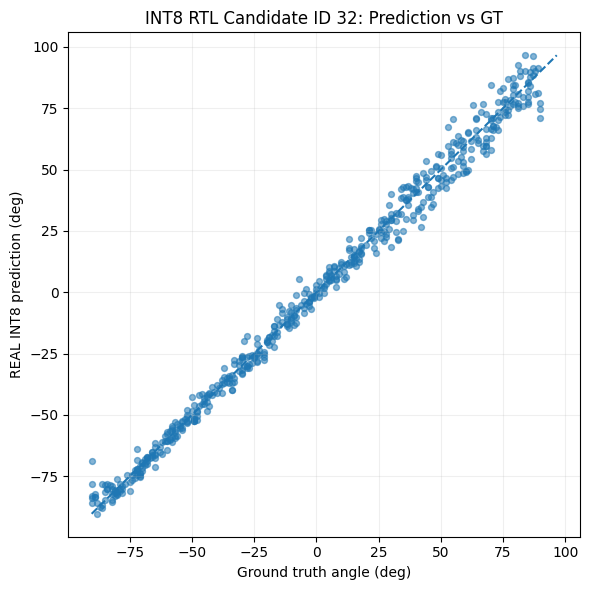

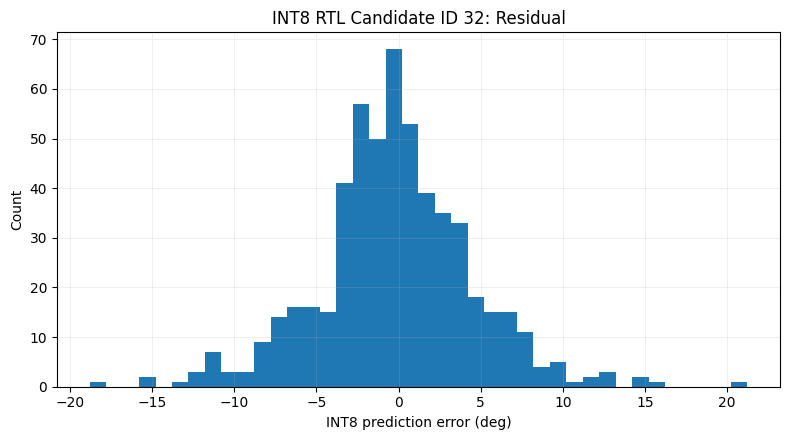

In [61]:
# ============================================================
# 22-7. Final test — ONLY the REAL-INT8-selected RTL candidate
# ============================================================
int8_selected_row = int8_ranked[int8_ranked['selected_for_int8_rtl']].iloc[0]
int8_selected_qmodel = int8_models[int8_selected_id]
int8_selected_cfg, int8_selected_fp32_model = load_fp32_finalist(int8_selected_id)

# Test set은 여기서 처음 INT8 최종 후보 평가에 사용합니다.
fp32_selected_test = evaluate(int8_selected_fp32_model.to(DEVICE), test_loader, nn.MSELoss())
int8_selected_fp32_model = int8_selected_fp32_model.to('cpu').eval()
int8_selected_test = evaluate_int8_reference(int8_selected_qmodel, test_loader)

print('=' * 96)
print('FINAL TEST — FP32 vs REAL SIGNED INT8')
print('=' * 96)
print('RTL candidate ID:', int8_selected_id)
print('\nFP32')
print('  MAE      : %.3f deg' % fp32_selected_test['mae_deg'])
print('  Acc ±3°  : %.2f %%' % fp32_selected_test['acc3'])
print('  Acc ±5°  : %.2f %%' % fp32_selected_test['acc5'])
print('  Acc ±10° : %.2f %%' % fp32_selected_test['acc10'])
print('  R²       : %.4f' % fp32_selected_test['r2'])
print('\nREAL INT8')
print('  MAE      : %.3f deg' % int8_selected_test['mae_deg'])
print('  Acc ±3°  : %.2f %%' % int8_selected_test['acc3'])
print('  Acc ±5°  : %.2f %%' % int8_selected_test['acc5'])
print('  Acc ±10° : %.2f %%' % int8_selected_test['acc10'])
print('  R²       : %.4f' % int8_selected_test['r2'])
print('\nDelta (INT8 - FP32)')
print('  MAE delta     : %+.3f deg' % (int8_selected_test['mae_deg'] - fp32_selected_test['mae_deg']))
print('  Acc ±5 delta  : %+.2f %%p' % (int8_selected_test['acc5'] - fp32_selected_test['acc5']))

# plots
plt.figure(figsize=(6,6))
plt.scatter(int8_selected_test['target_deg'], int8_selected_test['pred_deg'], s=18, alpha=0.55)
lo = min(int8_selected_test['target_deg'].min(), int8_selected_test['pred_deg'].min())
hi = max(int8_selected_test['target_deg'].max(), int8_selected_test['pred_deg'].max())
plt.plot([lo,hi],[lo,hi], linestyle='--')
plt.xlabel('Ground truth angle (deg)')
plt.ylabel('REAL INT8 prediction (deg)')
plt.title(f'INT8 RTL Candidate ID {int8_selected_id}: Prediction vs GT')
plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'REAL_INT8_prediction_vs_gt.png', dpi=170, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8,4.5))
plt.hist(int8_selected_test['pred_deg'] - int8_selected_test['target_deg'], bins=40)
plt.xlabel('INT8 prediction error (deg)')
plt.ylabel('Count')
plt.title(f'INT8 RTL Candidate ID {int8_selected_id}: Residual')
plt.grid(alpha=0.2); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'REAL_INT8_residual_hist.png', dpi=170, bbox_inches='tight')
plt.show()

In [62]:
# ============================================================
# 22-8. Quantization parameter inspection
# ============================================================
selected_calib = int8_calibrations[int8_selected_id]
print('[Activation calibration]')
display(show_calibration_table(selected_calib['absmax'], selected_calib['scales']))

print('\n[Weighted-layer quantization / requantization parameters]')
int8_layer_table = int8_selected_qmodel.layer_table()
display(int8_layer_table)
int8_layer_table.to_csv(INT8_EXPORT_DIR / 'quant_layer_params.csv', index=False)

print('\nFinal regression output scale (INT32 accumulator -> angle_norm):',
      int8_selected_qmodel.final_output_scale)
print('Angle degree conversion: angle_deg = final_acc_int32 * final_output_scale * 90.0')

[Activation calibration]


,tensor,absmax,scale,zero_point
0,__input__,1.000000,0.007874,0
1,features.1,0.913100,0.007190,0
2,features.4,1.218935,0.009598,0
3,regressor.1,3.063066,0.024119,0



[Weighted-layer quantization / requantization parameters]


,name,type,weight_shape,input_scale,weight_scale,output_scale,multiplier_real,multiplier_int32,right_shift,multiplier_rel_error,final_int32_output
0,features.0,conv2d,"(6, 3, 3, 3)",0.007874,0.001879,0.007190,0.002058,2209259.0,30.0,4.962404e-08,False
1,features.3,conv2d,"(4, 6, 3, 3)",0.007190,0.001511,0.009598,0.001132,1215363.0,30.0,3.820412e-07,False
2,regressor.0,linear,"(32, 4096)",0.009598,0.000745,0.024119,0.000297,318495.0,30.0,1.488060e-06,False
3,regressor.2,linear,"(1, 32)",0.024119,0.001577,NaN,NaN,NaN,NaN,NaN,True



Final regression output scale (INT32 accumulator -> angle_norm): 3.804070761132536e-05
Angle degree conversion: angle_deg = final_acc_int32 * final_output_scale * 90.0


In [63]:
# ============================================================
# 22-9. RTL export: INT8 weights / INT32 bias / params / layer-by-layer golden vectors
# ============================================================
def _sanitize(name):
    return name.replace('.', '_').replace('/', '_')


def _twos_hex(value: int, bits: int):
    mask = (1 << bits) - 1
    width = (bits + 3) // 4
    return f'{int(value) & mask:0{width}X}'


def save_mem_hex(path: Path, tensor: torch.Tensor, bits: int):
    arr = tensor.detach().cpu().reshape(-1).to(torch.int64).numpy()
    with open(path, 'w', encoding='utf-8') as f:
        for v in arr:
            f.write(_twos_hex(int(v), bits) + '\n')


def export_int8_rtl_model(qmodel: RTLInt8Reference, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    layer_json = []

    for li, d in enumerate(qmodel.weighted_layers):
        prefix = f'{li:02d}_{_sanitize(d["name"])}'
        w8 = d['weight_q'].to(torch.int8)
        b32 = d['bias_q'].to(torch.int32)

        np.save(out_dir / f'{prefix}_weight_int8.npy', w8.numpy())
        np.save(out_dir / f'{prefix}_bias_int32.npy', b32.numpy())
        save_mem_hex(out_dir / f'{prefix}_weight_int8.mem', w8, 8)
        save_mem_hex(out_dir / f'{prefix}_bias_int32.mem', b32, 32)

        info = {k: v for k, v in d.items() if k not in ['weight_q','bias_q']}
        # tuple -> JSON list
        for k, v in list(info.items()):
            if isinstance(v, tuple):
                info[k] = list(v)
        info['weight_mem_layout'] = (
            'PyTorch C-order flatten: Conv=[Cout,Cin,Kh,Kw], Linear=[Cout,Cin]'
        )
        layer_json.append(info)

    params = {
        'selected_int8_rtl_id': int(int8_selected_id),
        'quantization': {
            'scheme': 'symmetric_per_tensor',
            'weight_dtype': 'signed_int8',
            'activation_dtype': 'signed_int8',
            'accumulator_dtype': 'signed_int32',
            'bias_dtype': 'signed_int32',
            'qmin': int(INT8_QMIN),
            'qmax': int(INT8_QMAX),
            'zero_point': int(INT8_ZERO_POINT),
            'rounding': 'round_half_away_from_zero',
        },
        'input': {
            'layout': 'NCHW in Python; exported single-vector tensor uses CHW flatten',
            'shape': [3,64,64],
            'source_fp32_range': '[0,1] after ToTensor()',
            'scale': float(qmodel.input_scale),
            'zero_point': 0,
        },
        'layers': layer_json,
        'final_regression': {
            'representation': 'INT32 accumulator + scale (no final INT8 clipping)',
            'output_scale_angle_norm_per_lsb': float(qmodel.final_output_scale),
            'output_scale_degree_per_lsb': float(qmodel.final_output_scale * 90.0),
            'formula': 'angle_deg = final_acc_int32 * output_scale_angle_norm_per_lsb * 90.0',
        },
    }

    with open(out_dir / 'quant_params.json', 'w', encoding='utf-8') as f:
        json.dump(params, f, ensure_ascii=False, indent=2)

    readme = f"""V-TRAX REAL Signed INT8 RTL Export\n\nSelected RTL candidate ID: {int8_selected_id}\n\nQuantization\n- Weight: signed INT8, symmetric per-tensor, zero_point=0\n- Activation: signed INT8, symmetric per-tensor, zero_point=0\n- Bias / accumulator: signed INT32\n- Rounding: half away from zero\n- Hidden requant: q_out = clamp(round(acc * multiplier_int / 2^right_shift), 0..127 after ReLU)\n- Final regression: INT32 accumulator is NOT clipped to INT8.\n  angle_deg = final_acc_int32 * final_output_scale * 90.0\n\nMEM layout\n- Conv weight: PyTorch [Cout, Cin, Kh, Kw] C-order flatten\n- Linear weight: PyTorch [Cout, Cin] C-order flatten\n- INT8 .mem: 2-digit two's-complement HEX, one value per line\n- INT32 .mem: 8-digit two's-complement HEX, one value per line\n\nFor RTL comparison, use golden_vectors/ in numeric filename order.\n"""
    with open(out_dir / 'README_INT8_EXPORT.txt', 'w', encoding='utf-8') as f:
        f.write(readme)

export_int8_rtl_model(int8_selected_qmodel, INT8_EXPORT_DIR)

# ---------- One layer-by-layer test vector ----------
golden_dir = INT8_EXPORT_DIR / 'golden_vectors'
golden_dir.mkdir(parents=True, exist_ok=True)

x_vec, y_norm_vec, y_deg_vec = next(iter(test_loader))
x1 = x_vec[:1].cpu()
y1_norm = float(y_norm_vec[0].item())
y1_deg = float(y_deg_vec[0].item())
pred1_norm, trace = int8_selected_qmodel.forward_int8(x1, return_trace=True)
pred1_norm = float(pred1_norm[0].item())
pred1_deg = pred1_norm * 90.0

with torch.no_grad():
    fp32_pred1_norm = float(int8_selected_fp32_model(x1).item())
fp32_pred1_deg = fp32_pred1_norm * 90.0

trace_manifest = []
for name, (tensor, bits) in trace.items():
    arr = tensor.detach().cpu()
    np.save(golden_dir / f'{name}.npy', arr.numpy())
    save_mem_hex(golden_dir / f'{name}.mem', arr, bits)
    trace_manifest.append({
        'name': name,
        'bits': int(bits),
        'shape': list(arr.shape),
        'num_values': int(arr.numel()),
        'mem_order': 'C-order flatten of shown tensor shape',
    })

vector_summary = {
    'ground_truth_angle_norm': y1_norm,
    'ground_truth_angle_deg': y1_deg,
    'fp32_pred_angle_norm': fp32_pred1_norm,
    'fp32_pred_angle_deg': fp32_pred1_deg,
    'int8_pred_angle_norm': pred1_norm,
    'int8_pred_angle_deg': pred1_deg,
    'trace': trace_manifest,
}
with open(golden_dir / 'golden_vector_summary.json', 'w', encoding='utf-8') as f:
    json.dump(vector_summary, f, ensure_ascii=False, indent=2)

print('RTL export complete:', INT8_EXPORT_DIR)
print('Golden vector GT / FP32 / INT8 [deg]:', y1_deg, fp32_pred1_deg, pred1_deg)

RTL export complete: /content/vtrax_arch_search_outputs/int8_rtl_export
Golden vector GT / FP32 / INT8 [deg]: -63.0 -64.43937420845032 -65.3063847917428


In [64]:
# ============================================================
# 22-10. Save REAL INT8 summary
# ============================================================
int8_summary = {
    'selected_int8_rtl_id': int(int8_selected_id),
    'config': int8_selected_cfg,
    'validation_int8': {
        'mae_deg': float(int8_selected_row.val_mae_deg),
        'acc3': float(int8_selected_row.val_acc3),
        'acc5': float(int8_selected_row.val_acc5),
        'acc10': float(int8_selected_row.val_acc10),
        'r2': float(int8_selected_row.val_r2),
    },
    'test_fp32': {k: float(fp32_selected_test[k]) for k in ['loss','mae_deg','acc3','acc5','acc10','r2']},
    'test_int8': {k: float(int8_selected_test[k]) for k in ['loss','mae_deg','acc3','acc5','acc10','r2']},
    'test_delta_int8_minus_fp32': {
        'mae_deg': float(int8_selected_test['mae_deg'] - fp32_selected_test['mae_deg']),
        'acc5_pp': float(int8_selected_test['acc5'] - fp32_selected_test['acc5']),
    },
    'final_output_scale_angle_norm_per_lsb': float(int8_selected_qmodel.final_output_scale),
    'final_output_scale_degree_per_lsb': float(int8_selected_qmodel.final_output_scale * 90.0),
}
with open(OUTPUT_DIR / 'REAL_INT8_final_summary.json', 'w', encoding='utf-8') as f:
    json.dump(int8_summary, f, ensure_ascii=False, indent=2, default=str)

print(json.dumps(int8_summary, ensure_ascii=False, indent=2, default=str))

{
  "selected_int8_rtl_id": 32,
  "config": {
    "id": "32",
    "stem_stride": "1",
    "n_extra_conv": "1",
    "channels": [
      4
    ],
    "strides": [
      1
    ],
    "pool_between": [
      1
    ],
    "head": "flatten",
    "fc_depth": "2",
    "fc_hidden": [
      32
    ]
  },
  "validation_int8": {
    "mae_deg": 3.470008613972476,
    "acc3": 57.2744014732965,
    "acc5": 79.00552486187846,
    "acc10": 94.65930018416206,
    "r2": 0.9914011975931123
  },
  "test_fp32": {
    "loss": 0.0027981269008973066,
    "mae_deg": 3.498323174083934,
    "acc3": 55.88235294117647,
    "acc5": 75.91911764705883,
    "acc10": 95.03676470588235,
    "r2": 0.9917436838150024
  },
  "test_int8": {
    "loss": 0.002780763791028689,
    "mae_deg": 3.504091359345889,
    "acc3": 56.25,
    "acc5": 75.91911764705883,
    "acc10": 94.8529411764706,
    "r2": 0.9917949442203938
  },
  "test_delta_int8_minus_fp32": {
    "mae_deg": 0.0057681852619548835,
    "acc5_pp": 0.0
  },
  "final_o

## INT8 결과 해석

이 v7 노트북에서 `REAL INT8`이라고 표시되는 정확도는 **실제 quantized weight와 quantized activation을 사용한 integer-reference 결과**입니다.

따라서 다음 값들을 구분해서 보시면 됩니다.

- 기존 `INT8 Weight (KB)`: architecture search 단계의 메모리 비용 추정
- `fp32_val_acc5`: FP32 finalist validation 정확도
- `val_acc5` in `final_ranked_REAL_INT8_PTQ.csv`: 실제 signed INT8 PTQ validation 정확도
- `selected_for_int8_rtl=True`: INT8 accuracy/MAE gate를 다시 적용한 최종 RTL 후보
- `REAL_INT8_final_summary.json`: 최종 후보의 FP32/INT8 test 비교
- `int8_rtl_export/quant_params.json`: RTL scale / requant multiplier / shift
- `int8_rtl_export/*.mem`: ROM/BRAM 초기화 또는 RTL testbench에 사용할 weight/bias 값
- `int8_rtl_export/golden_vectors/`: layer-by-layer RTL 비교용 golden tensor

현재 weight quantization은 RTL 단순성을 위해 **per-tensor symmetric**입니다. INT8 accuracy drop이 크면 다음 단계는 `per-channel weight PTQ` 또는 `QAT`입니다.

In [65]:
# ============================================================
# 23. Zip ALL results (including REAL INT8 RTL export)
# ============================================================
archive_base = '/content/VTRAX_v7_REAL_INT8_RTL_results'
archive_path = shutil.make_archive(archive_base, 'zip', OUTPUT_DIR)
print('Saved:', archive_path)

try:
    from google.colab import files
    # 자동 다운로드가 싫으면 다음 줄을 주석 처리하세요.
    # files.download(archive_path)
except Exception:
    pass

Saved: /content/VTRAX_v7_REAL_INT8_RTL_results.zip
